In [1]:
library(coloc)
library(vroom)
library(stringr)
library(dplyr)
library(ggplot2)
library(parallel)
library(GenomicRanges)
library(igraph)
library(UpSetR)
library(tidyr)

This is coloc version 5.2.3


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required pa

In [2]:
modalities <- c('RNA','ATAC','H3K27ac','H3K27me3')

for (cell in c('B','T','NK','Hepatocytes','Endothelial','Myeloid','HSC','Cholangiocyte','Bulk')) {  
    message(cell)
    
    ### Create GRanges for each modality
    for (mod in modalities) {
        message(mod)
        # Get modality specific paths
        if (mod == 'RNA') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/counts/',
                                 cell,'_perdonor.RNA.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        } else if (mod == 'ATAC') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/counts/',
                                 cell,'_perdonor.ATAC.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/',
                                 cell,'.cis_qtl.txt.gz')
        } else if (mod == 'H3K27ac') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/counts/',
                                 cell,'_perdonor.H3K27ac.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        }else if (mod == 'H3K27me3') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/counts/',
                                 cell,'_perdonor.H3K27me3.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        }
        
        ### Read in data for the first modality and add columns
        counts <- read.table(count.path)
        counts$modality <- mod
        counts$cell <- cell
        
        qtl.feature.res <- read.table(feature.res.path, header=T)
        counts <- left_join(counts, select(qtl.feature.res, phenotype_id, variant_id), by=join_by(V4==phenotype_id))
        qtl.feature.res <- filter(qtl.feature.res, qval < 0.05)
        
        counts$sig <- FALSE
        if (nrow(qtl.feature.res) > 0) {
            counts[counts$V4 %in% qtl.feature.res$phenotype_id,]$sig <- TRUE
        }
        
        message(nrow(qtl.feature.res))
        message(sum(counts$sig))
        message(nrow(counts))
        
        ### Construct GRanges object
        gr <- GRanges(seqnames = counts[,1], ranges = IRanges(start = as.numeric(counts[,2]), end = as.numeric(counts[,3])),
                        mcols=select(counts, modality, feature=V4, cell, sig, variant_id))
        gr <- restrict(resize(gr, width = width(gr) + 2e6, fix = "center"), start=0)
    
        gc()
        
        write.table(data.frame(gr), paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/',
                                   mod,'.',cell,'.feature.1MB.bed'), col.names=F, row.names=F, quote=F, sep='\t')
        write.table(filter(data.frame(gr), mcols.sig), paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/',
                                   mod,'.',cell,'.feature.1MB.fdr.bed'), col.names=F, row.names=F, quote=F, sep='\t')
    }
}

B

RNA

7

7

6932

ATAC

6

6

20801

H3K27ac

0

0

13285

H3K27me3

0

0

1247

T

RNA

21

21

7028

ATAC

54

54

25867

H3K27ac

1

1

16392

H3K27me3

0

0

14085

NK

RNA

23

23

6234

ATAC

16

16

21681

H3K27ac

0

0

9386

H3K27me3

0

0

2634

Hepatocytes

RNA

871

871

20235

ATAC

6106

6106

549326

H3K27ac

370

370

262385

H3K27me3

388

388

428811

Endothelial

RNA

293

293

15465

ATAC

1855

1855

147882

H3K27ac

33

33

105716

H3K27me3

0

0

116452

Myeloid

RNA

284

284

13734

ATAC

2047

2047

170862

H3K27ac

14

14

112802

H3K27me3

2

2

268971

HSC

RNA

94

94

13657

ATAC

443

443

115352

H3K27ac

0

0

45602

H3K27me3

0

0

21097

Cholangiocyte

RNA

51

51

11124

ATAC

64

64

45352

H3K27ac

0

0

63724

H3K27me3

1

1

87463

Bulk

RNA

961

961

23377

ATAC

7299

7299

607565

H3K27ac

442

442

379840

H3K27me3

356

356

458349



In [ ]:
# From /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/ on TSCC

for cell in B Bulk Cholangiocyte Endothelial Hepatocytes HSC Myeloid NK T; do
    bedtools intersect -a RNA.$cell.feature.1MB.fdr.bed     -b ATAC.$cell.feature.1MB.fdr.bed     -wa -wb > ../overlaps/$cell.RNA.ATAC.1MB.fdr.bed
    bedtools intersect -a RNA.$cell.feature.1MB.fdr.bed     -b H3K27ac.$cell.feature.1MB.fdr.bed  -wa -wb > ../overlaps/$cell.RNA.H3K27ac.1MB.fdr.bed
    bedtools intersect -a RNA.$cell.feature.1MB.fdr.bed     -b H3K27me3.$cell.feature.1MB.fdr.bed -wa -wb > ../overlaps/$cell.RNA.H3K27me3.1MB.fdr.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.fdr.bed    -b H3K27ac.$cell.feature.1MB.fdr.bed  -wa -wb > ../overlaps/$cell.ATAC.H3K27ac.1MB.fdr.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.fdr.bed    -b H3K27me3.$cell.feature.1MB.fdr.bed -wa -wb > ../overlaps/$cell.ATAC.H3K27me3.1MB.fdr.bed
    bedtools intersect -a H3K27ac.$cell.feature.1MB.fdr.bed -b H3K27me3.$cell.feature.1MB.fdr.bed -wa -wb > ../overlaps/$cell.H3K27ac.H3K27me3.1MB.fdr.bed

    bedtools intersect -a RNA.$cell.feature.1MB.bed     -b ATAC.$cell.feature.1MB.bed     -wa -wb > ../overlaps/$cell.RNA.ATAC.1MB.bed
    bedtools intersect -a RNA.$cell.feature.1MB.bed     -b H3K27ac.$cell.feature.1MB.bed  -wa -wb > ../overlaps/$cell.RNA.H3K27ac.1MB.bed
    bedtools intersect -a RNA.$cell.feature.1MB.bed     -b H3K27me3.$cell.feature.1MB.bed -wa -wb > ../overlaps/$cell.RNA.H3K27me3.1MB.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.bed    -b H3K27ac.$cell.feature.1MB.bed  -wa -wb > ../overlaps/$cell.ATAC.H3K27ac.1MB.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.bed    -b H3K27me3.$cell.feature.1MB.bed -wa -wb > ../overlaps/$cell.ATAC.H3K27me3.1MB.bed
    bedtools intersect -a H3K27ac.$cell.feature.1MB.bed -b H3K27me3.$cell.feature.1MB.bed -wa -wb > ../overlaps/$cell.H3K27ac.H3K27me3.1MB.bed
done

In [ ]:
# From /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/ on TSCC

for cell in B Bulk Cholangiocyte Endothelial Hepatocytes HSC Myeloid NK T; do
    bedtools intersect -a RNA.$cell.feature.1MB.fdr.bed      -b RNA.$cell.feature.1MB.fdr.bed      -wa -wb > ../overlaps/$cell.RNA.RNA.1MB.fdr.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.fdr.bed     -b ATAC.$cell.feature.1MB.fdr.bed     -wa -wb > ../overlaps/$cell.ATAC.ATAC.1MB.fdr.bed
    bedtools intersect -a H3K27ac.$cell.feature.1MB.fdr.bed  -b H3K27ac.$cell.feature.1MB.fdr.bed  -wa -wb > ../overlaps/$cell.H3K27ac.H3K27ac.1MB.fdr.bed
    bedtools intersect -a H3K27me3.$cell.feature.1MB.fdr.bed -b H3K27me3.$cell.feature.1MB.fdr.bed -wa -wb > ../overlaps/$cell.H3K27me3.H3K27me3.1MB.fdr.bed

    bedtools intersect -a RNA.$cell.feature.1MB.bed      -b RNA.$cell.feature.1MB.bed      -wa -wb > ../overlaps/$cell.RNA.RNA.1MB.bed
    bedtools intersect -a ATAC.$cell.feature.1MB.bed     -b ATAC.$cell.feature.1MB.bed     -wa -wb > ../overlaps/$cell.ATAC.ATAC.1MB.bed
    bedtools intersect -a H3K27ac.$cell.feature.1MB.bed  -b H3K27ac.$cell.feature.1MB.bed  -wa -wb > ../overlaps/$cell.H3K27ac.H3K27ac.1MB.bed
    bedtools intersect -a H3K27me3.$cell.feature.1MB.bed -b H3K27me3.$cell.feature.1MB.bed -wa -wb > ../overlaps/$cell.H3K27me3.H3K27me3.1MB.bed
done

# Now coloc them

In [93]:
# In bash on TSCC  

cd /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas
conda activate coloc.susie

for bed in *.fdr.bed; do
    srun --job-name=$bed --output=../log/$bed.log --error=../log/$bed.err --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=128G --account=csd854 -t 24:00:00 -p condo -q condo Rscript --vanilla coloc.2feat.R $bed &
    sleep 5
done

[1] "phenotype_id.RNA"    "variant_id"          "start_distance.RNA" 
 [4] "af.RNA"              "ma_samples.RNA"      "ma_count.RNA"       
 [7] "pval_nominal.RNA"    "slope.RNA"           "slope_se.RNA"       
[10] "phenotype_id.ATAC"   "start_distance.ATAC" "end_distance"       
[13] "af.ATAC"             "ma_samples.ATAC"     "ma_count.ATAC"      
[16] "pval_nominal.ATAC"   "slope.ATAC"          "slope_se.ATAC"      
[19] "pos.hg38"

In [ ]:
for bed in *RNA.RNA*.fdr.bed *ATAC.ATAC*.fdr.bed *H3K27ac.H3K27ac*.fdr.bed *H3K27me3.H3K27me3*.fdr.bed; do
    srun --job-name=$bed --output=../log/$bed.log --error=../log/$bed.err --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=128G --account=csd854 -t 24:00:00 -p condo -q condo Rscript --vanilla coloc.2feat.R $bed &
    sleep 5
done

# Build Modules

In [170]:
subcluster_modules <- function(modules, graph, cluster) {
    for (i in unique(membership(cluster))) {
        # Extract the subgraph for the cluster
        subgraph <- induced_subgraph(graph, which(membership(cluster) == i))
        
        # Calculate modularity of the subgraph
        mod <- modularity(cluster, V(subgraph))
        
        # Step 3: Recursively cluster if modularity > 0.3
        if (mod > 0.3) {
            sub_clusters <- cluster_louvain(subgraph)
            modules <- subcluster_modules(modules, subgraph, sub_clusters)
        } else {
            modules[[length(modules) + 1]] <- subgraph
        }
    }
    return(modules)
}

In [171]:
in.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/coloc.res/'

In [172]:
list.files(in.dir)

[1] "B.ATAC.ATAC.1MB.fdr.bed.results"                    
 [2] "B.RNA.RNA.1MB.fdr.bed.results"                      
 [3] "Bulk.ATAC.H3K27ac.1MB.fdr.bed.results"              
 [4] "Bulk.ATAC.H3K27me3.1MB.fdr.bed.results"             
 [5] "Bulk.H3K27ac.H3K27ac.1MB.fdr.bed.results"           
 [6] "Bulk.H3K27ac.H3K27me3.1MB.fdr.bed.results"          
 [7] "Bulk.H3K27me3.H3K27me3.1MB.fdr.bed.results"         
 [8] "Bulk.RNA.ATAC.1MB.fdr.bed.results"                  
 [9] "Bulk.RNA.H3K27ac.1MB.fdr.bed.results"               
[10] "Bulk.RNA.H3K27me3.1MB.fdr.bed.results"              
[11] "Bulk.RNA.RNA.1MB.fdr.bed.results"                   
[12] "Cholangiocyte.ATAC.ATAC.1MB.fdr.bed.results"        
[13] "Cholangiocyte.H3K27me3.H3K27me3.1MB.fdr.bed.results"
[14] "Cholangiocyte.RNA.ATAC.1MB.fdr.bed.results"         
[15] "Cholangiocyte.RNA.RNA.1MB.fdr.bed.results"          
[16] "Endothelial.ATAC.ATAC.1MB.fdr.bed.results"          
[17] "Endothelial.ATAC.H3K27ac.1MB.fdr.bed.results"       
[18] "Endothelial.H3K27ac.H3K27ac.1MB.fdr.bed.results"    
[19] "Endothelial.RNA.ATAC.1MB.fdr.bed.results"           
[20] "Endothelial.RNA.H3K27ac.1MB.fdr.bed.results"        
[21] "Endothelial.RNA.RNA.1MB.fdr.bed.results"            
[22] "graph_objects"                                      
[23] "Hepatocytes.ATAC.ATAC.1MB.fdr.bed.results"          
[24] "Hepatocytes.ATAC.H3K27ac.1MB.fdr.bed.results"       
[25] "Hepatocytes.ATAC.H3K27me3.1MB.fdr.bed.results"      
[26] "Hepatocytes.H3K27ac.H3K27ac.1MB.fdr.bed.results"    
[27] "Hepatocytes.H3K27ac.H3K27me3.1MB.fdr.bed.results"   
[28] "Hepatocytes.H3K27me3.H3K27me3.1MB.fdr.bed.results"  
[29] "Hepatocytes.RNA.ATAC.1MB.fdr.bed.results"           
[30] "Hepatocytes.RNA.H3K27ac.1MB.fdr.bed.results"        
[31] "Hepatocytes.RNA.H3K27me3.1MB.fdr.bed.results"       
[32] "Hepatocytes.RNA.RNA.1MB.fdr.bed.results"            
[33] "HSC.ATAC.ATAC.1MB.fdr.bed.results"                  
[34] "HSC.RNA.ATAC.1MB.fdr.bed.results"                   
[35] "HSC.RNA.RNA.1MB.fdr.bed.results"                    
[36] "Myeloid.ATAC.ATAC.1MB.fdr.bed.results"              
[37] "Myeloid.ATAC.H3K27ac.1MB.fdr.bed.results"           
[38] "Myeloid.ATAC.H3K27me3.1MB.fdr.bed.results"          
[39] "Myeloid.H3K27ac.H3K27ac.1MB.fdr.bed.results"        
[40] "Myeloid.H3K27me3.H3K27me3.1MB.fdr.bed.results"      
[41] "Myeloid.RNA.ATAC.1MB.fdr.bed.results"               
[42] "Myeloid.RNA.H3K27ac.1MB.fdr.bed.results"            
[43] "Myeloid.RNA.H3K27me3.1MB.fdr.bed.results"           
[44] "Myeloid.RNA.RNA.1MB.fdr.bed.results"                
[45] "NK.ATAC.ATAC.1MB.fdr.bed.results"                   
[46] "NK.RNA.ATAC.1MB.fdr.bed.results"                    
[47] "NK.RNA.RNA.1MB.fdr.bed.results"                     
[48] "old"                                                
[49] "T.ATAC.ATAC.1MB.fdr.bed.results"                    
[50] "T.H3K27ac.H3K27ac.1MB.fdr.bed.results"              
[51] "T.RNA.ATAC.1MB.fdr.bed.results"                     
[52] "T.RNA.RNA.1MB.fdr.bed.results"

In [173]:
cell <- 'Hepatocytes'
for (file in list.files(in.dir)[str_detect(list.files(in.dir), paste0('^',cell))]) {
        print(file)
    }

[1] "Hepatocytes.ATAC.ATAC.1MB.fdr.bed.results"
[1] "Hepatocytes.ATAC.H3K27ac.1MB.fdr.bed.results"
[1] "Hepatocytes.ATAC.H3K27me3.1MB.fdr.bed.results"
[1] "Hepatocytes.H3K27ac.H3K27ac.1MB.fdr.bed.results"
[1] "Hepatocytes.H3K27ac.H3K27me3.1MB.fdr.bed.results"
[1] "Hepatocytes.H3K27me3.H3K27me3.1MB.fdr.bed.results"
[1] "Hepatocytes.RNA.ATAC.1MB.fdr.bed.results"
[1] "Hepatocytes.RNA.H3K27ac.1MB.fdr.bed.results"
[1] "Hepatocytes.RNA.H3K27me3.1MB.fdr.bed.results"
[1] "Hepatocytes.RNA.RNA.1MB.fdr.bed.results"


[1] "B"
          modality.2
modality.1 ATAC RNA
      ATAC    8   0
      RNA     0   7
[1] "Number of modules for B: 13"
[1] "Number of multi-QTL modules for B:0"
[1] "Number of singleton QTLs B:13"
[1] "SKIPPING HISTOGRAM - NO MULTI FEATURE MODULES"


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


[1] "SKIPPING MULTI UPSET PLOT - NO MULTI FEATURE MODULES"
[1] "Cholangiocyte"
          modality.2
modality.1 ATAC H3K27me3 RNA
  ATAC       76        0   0
  H3K27me3    0        1   0
  RNA         4        0  63
[1] "Number of modules for Cholangiocyte: 113"
[1] "Number of multi-QTL modules for Cholangiocyte:3"
[1] "Number of singleton QTLs Cholangiocyte:110"


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


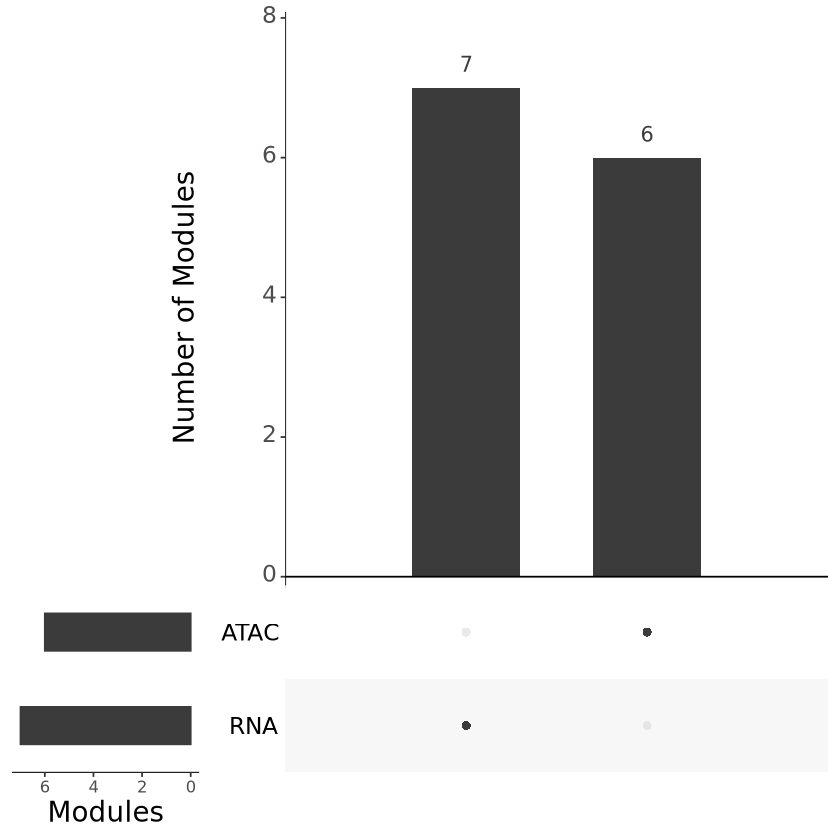

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


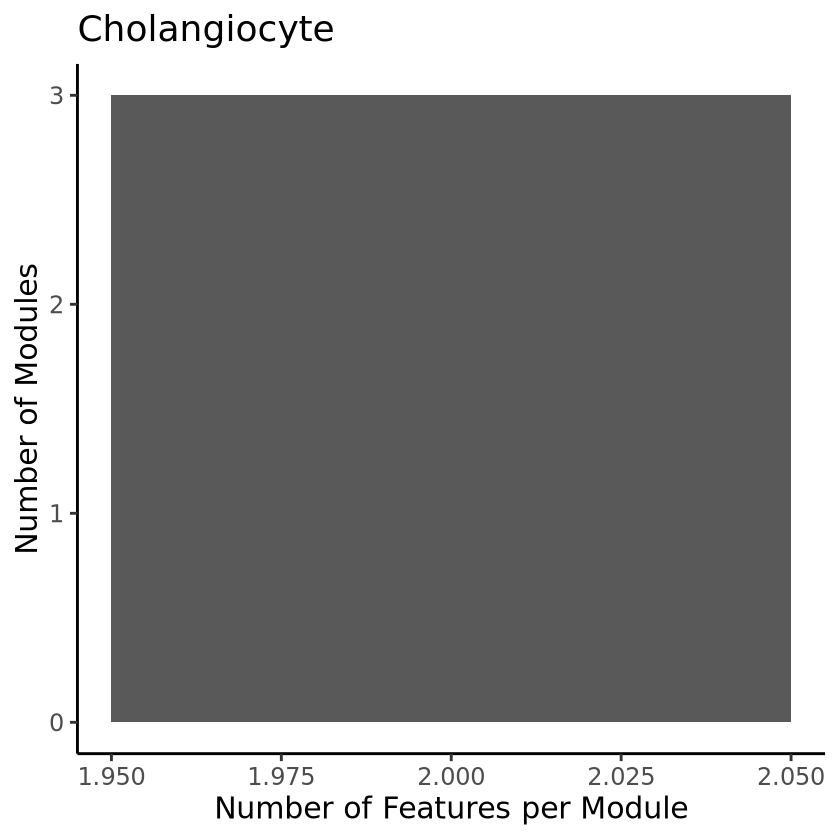

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


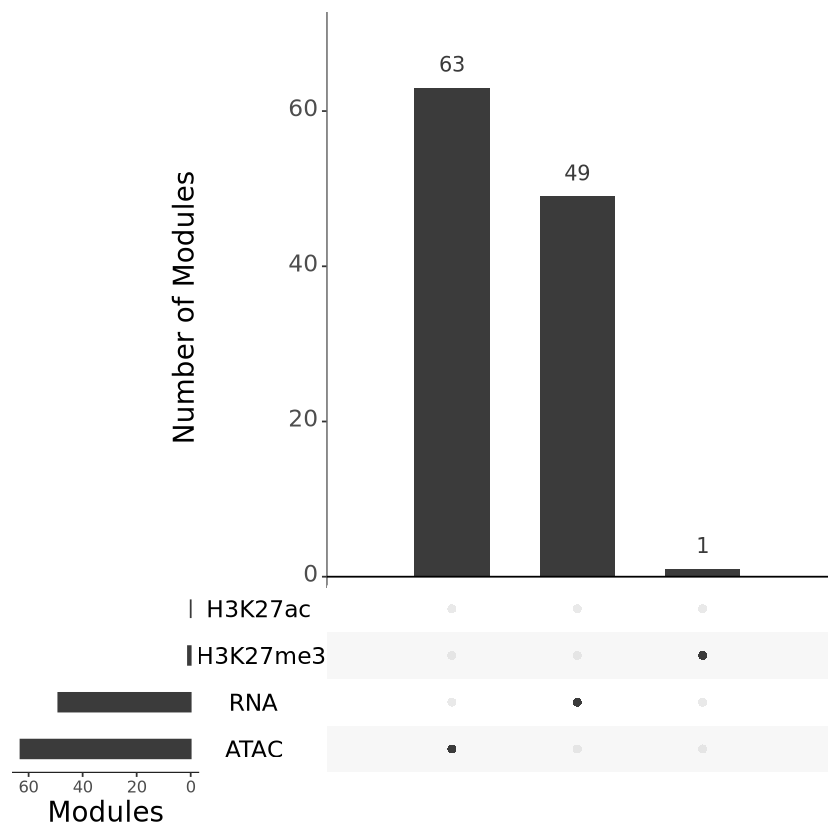

[1] "Endothelial"
          modality.2
modality.1 ATAC H3K27ac  RNA
   ATAC    7571      52    0
   H3K27ac    0      33    0
   RNA      203       6  421
[1] "Number of modules for Endothelial: 1452"
[1] "Number of multi-QTL modules for Endothelial:308"
[1] "Number of singleton QTLs Endothelial:1144"


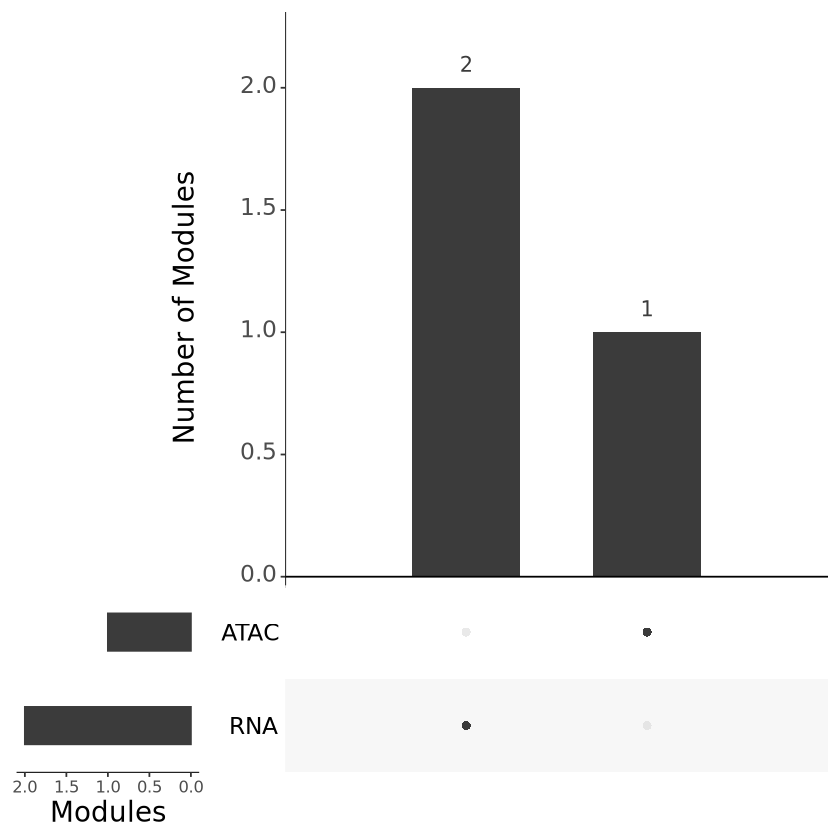

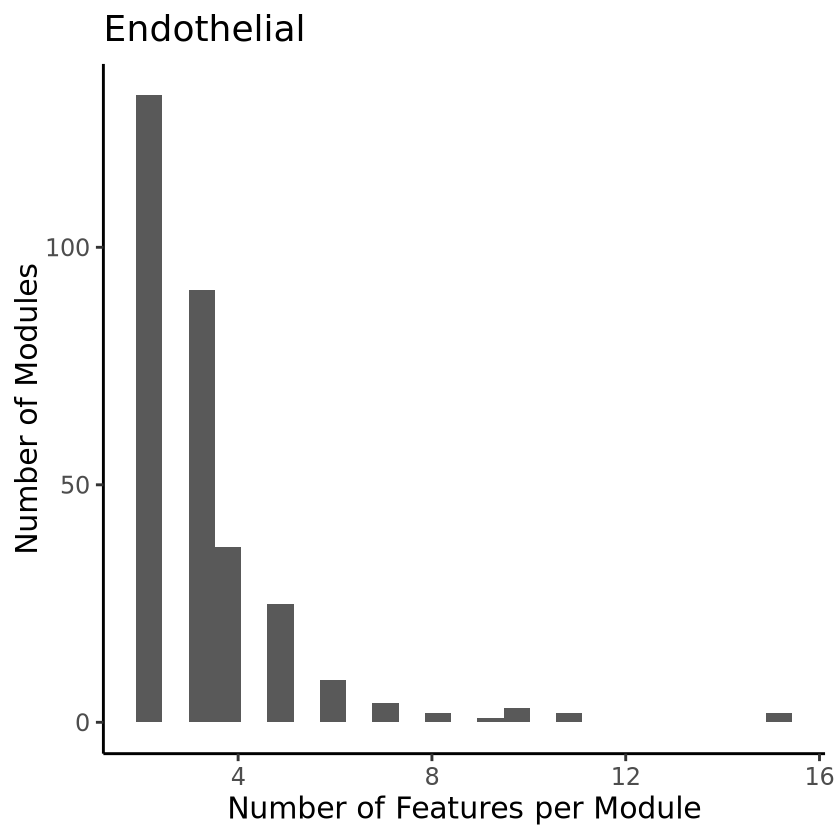

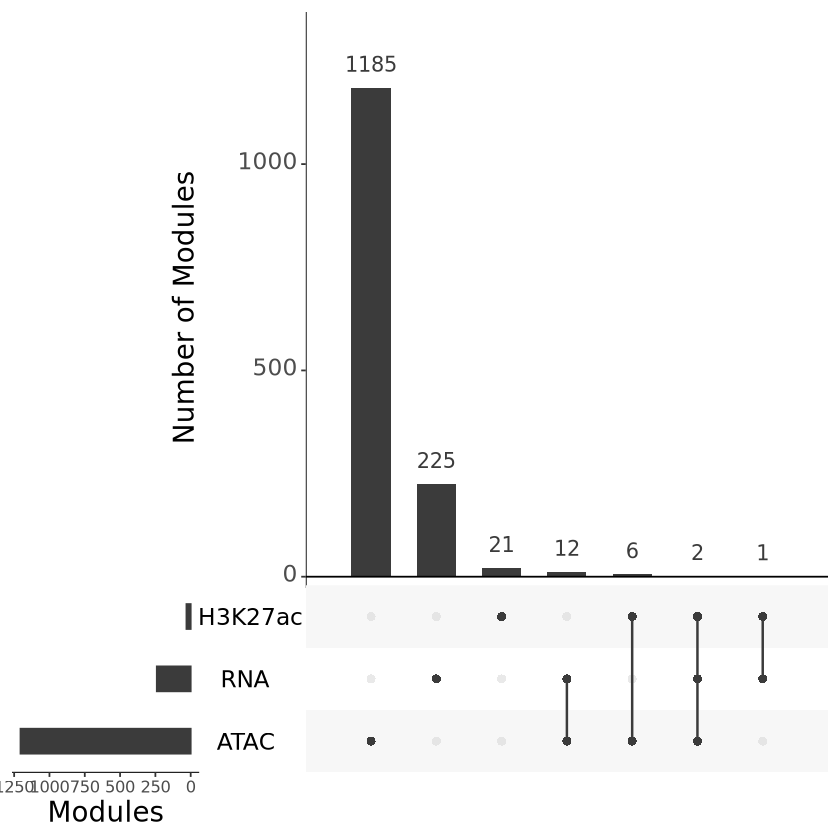

[1] "Hepatocytes"
          modality.2
modality.1  ATAC H3K27ac H3K27me3   RNA
  ATAC     53462    1454     3462     0
  H3K27ac      0     815      512     0
  H3K27me3     0       0    14835     0
  RNA       1032     132      601  2056
[1] "Number of modules for Hepatocytes: 3235"
[1] "Number of multi-QTL modules for Hepatocytes:1232"
[1] "Number of singleton QTLs Hepatocytes:2003"


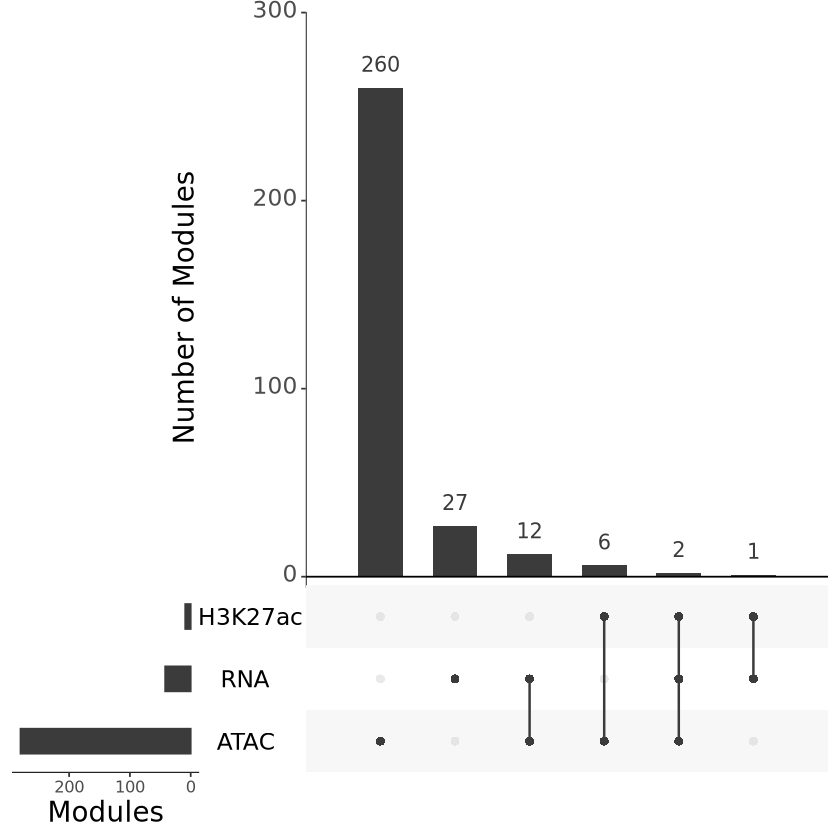

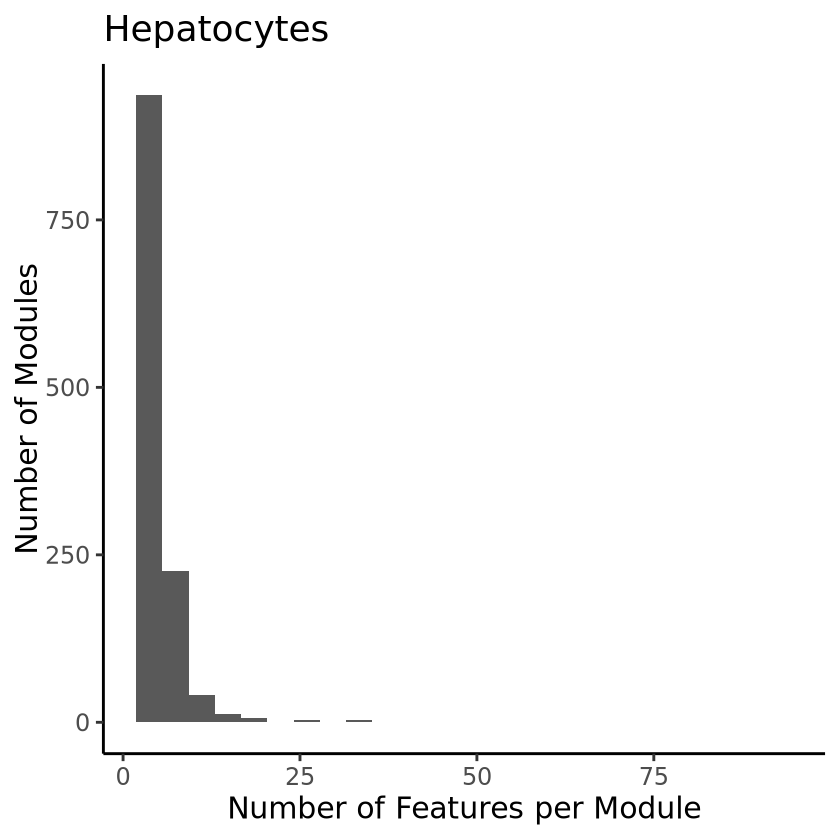

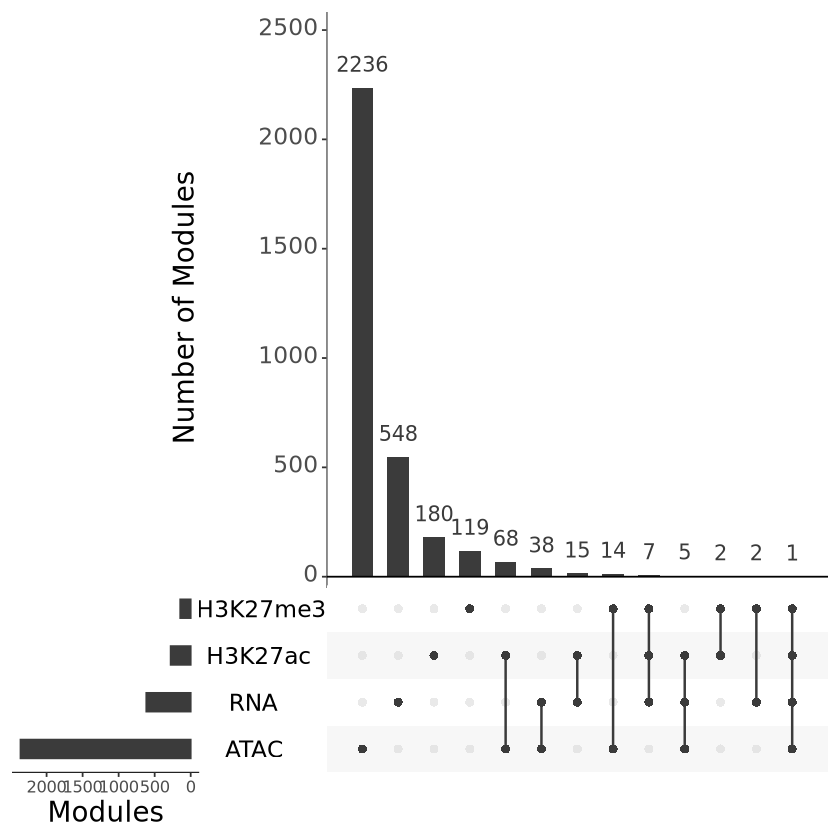

[1] "HSC"
          modality.2
modality.1 ATAC RNA
      ATAC  915   0
      RNA    13 112
[1] "Number of modules for HSC: 483"
[1] "Number of multi-QTL modules for HSC:22"
[1] "Number of singleton QTLs HSC:461"


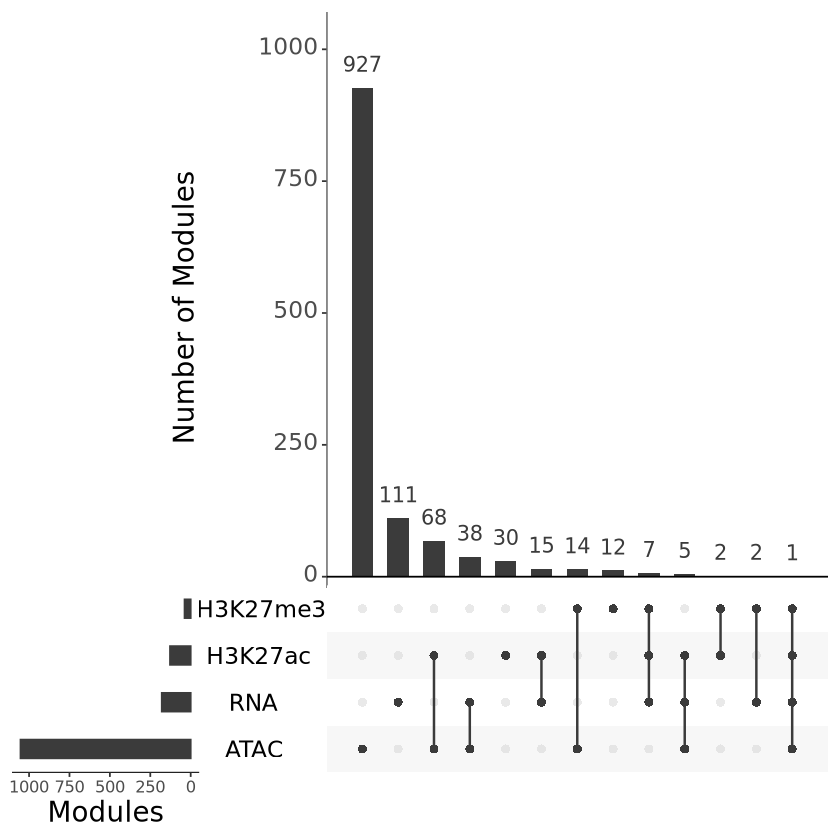

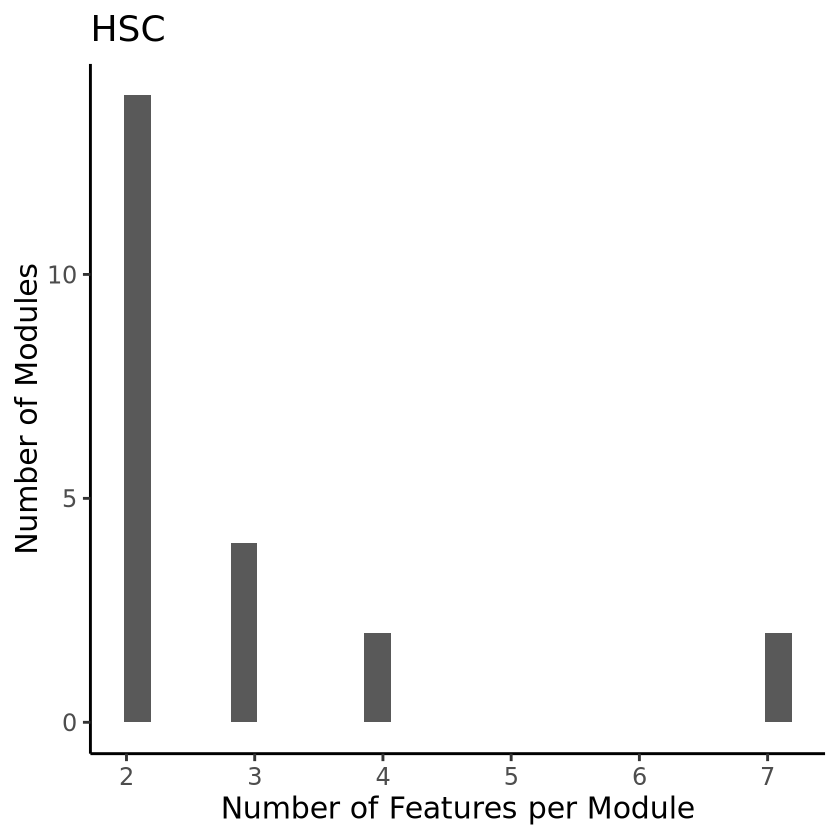

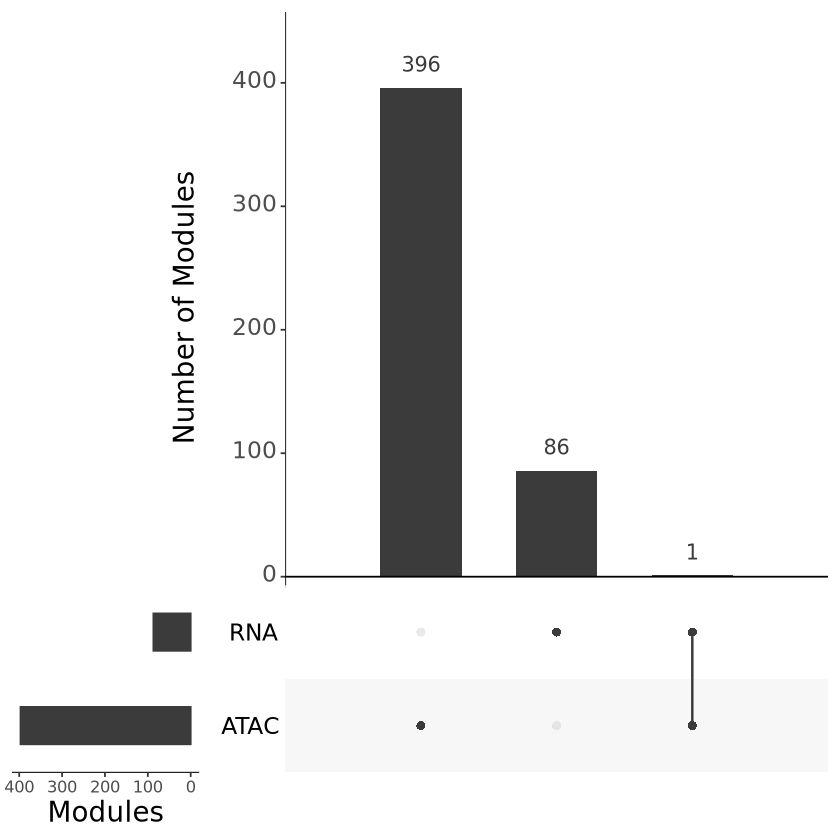

[1] "Myeloid"
          modality.2
modality.1 ATAC H3K27ac H3K27me3  RNA
  ATAC     8306      25        1    0
  H3K27ac     0      16        0    0
  H3K27me3    0       0        4    0
  RNA       106       1        3  408
[1] "Number of modules for Myeloid: 1587"
[1] "Number of multi-QTL modules for Myeloid:335"
[1] "Number of singleton QTLs Myeloid:1252"


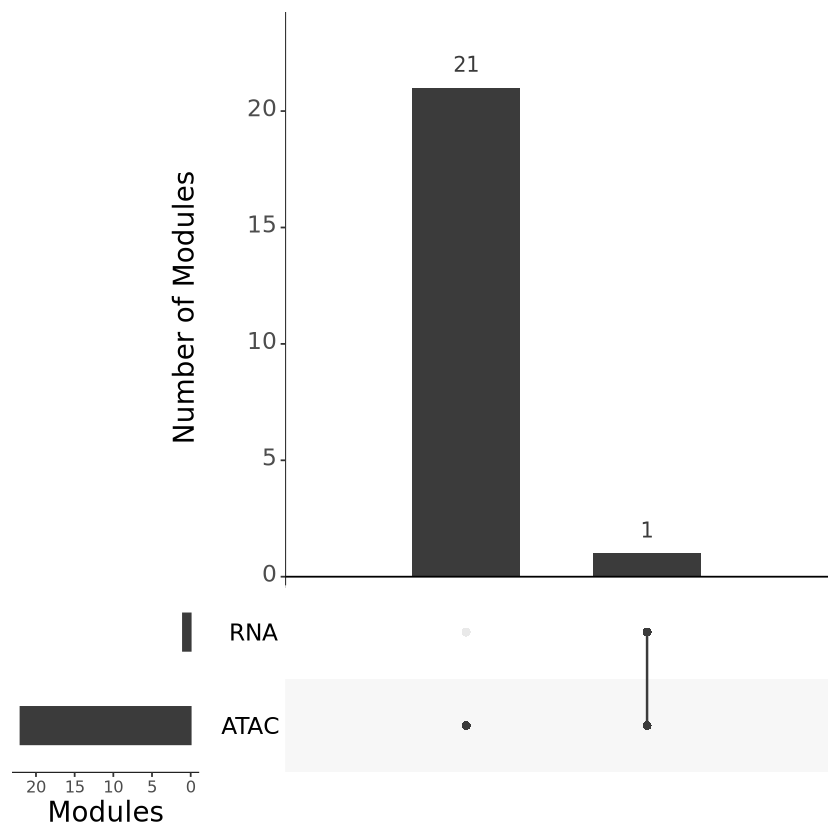

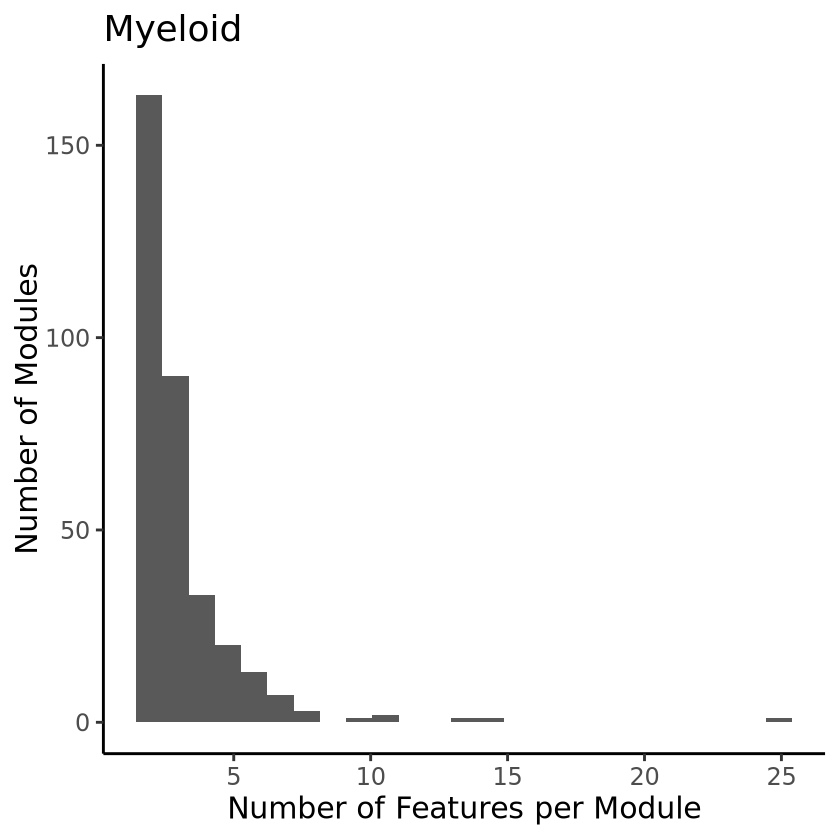

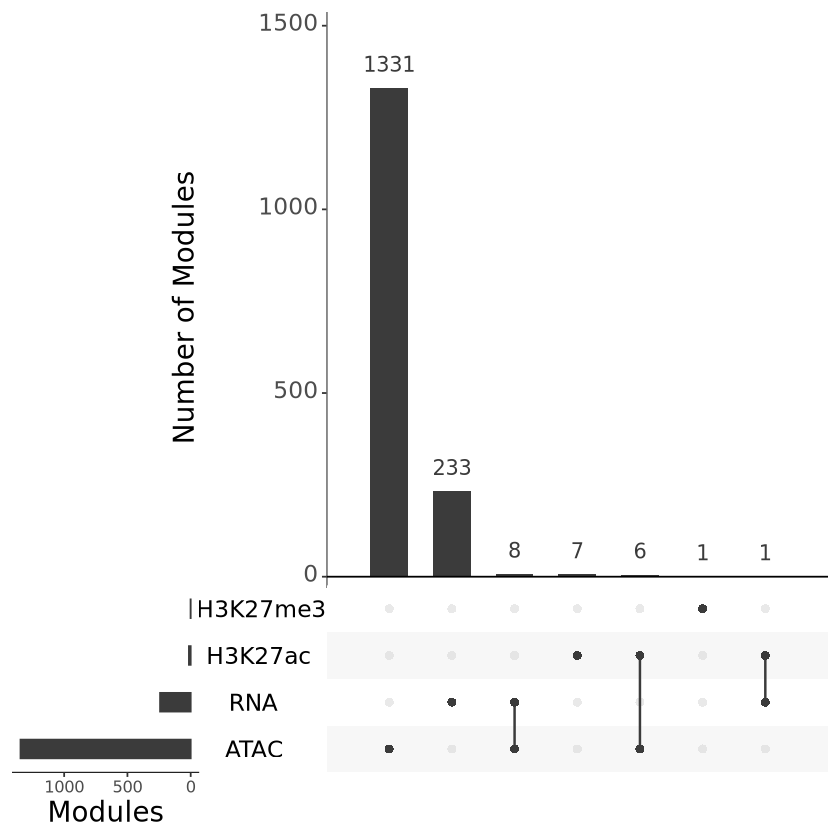

[1] "NK"
          modality.2
modality.1 ATAC RNA
      ATAC   20   0
      RNA     1  33
[1] "Number of modules for NK: 38"
[1] "Number of multi-QTL modules for NK:1"
[1] "Number of singleton QTLs NK:37"


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


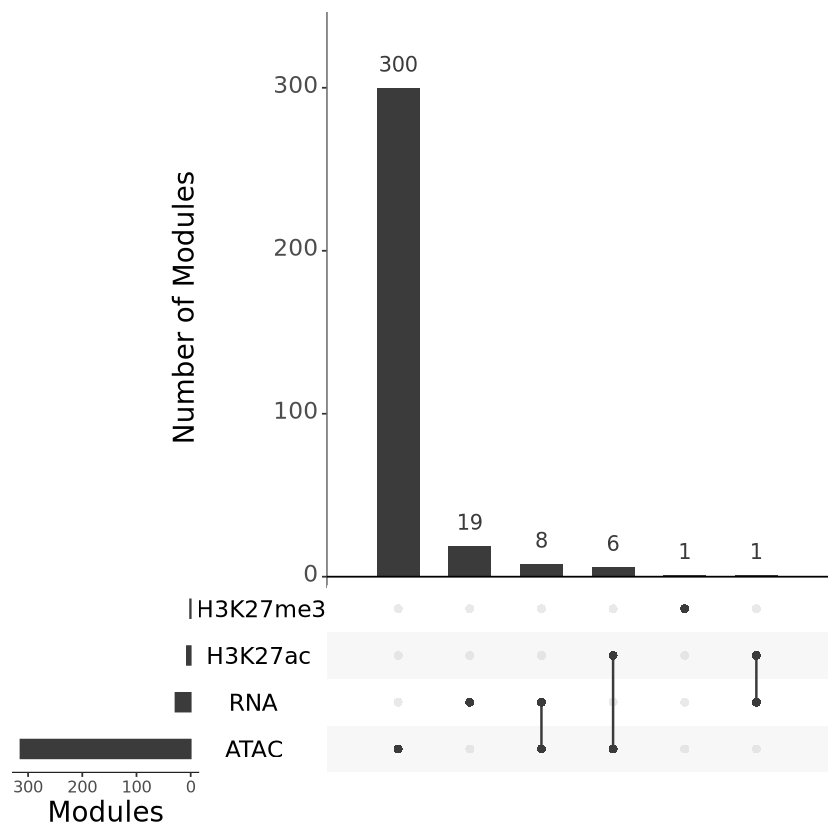

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


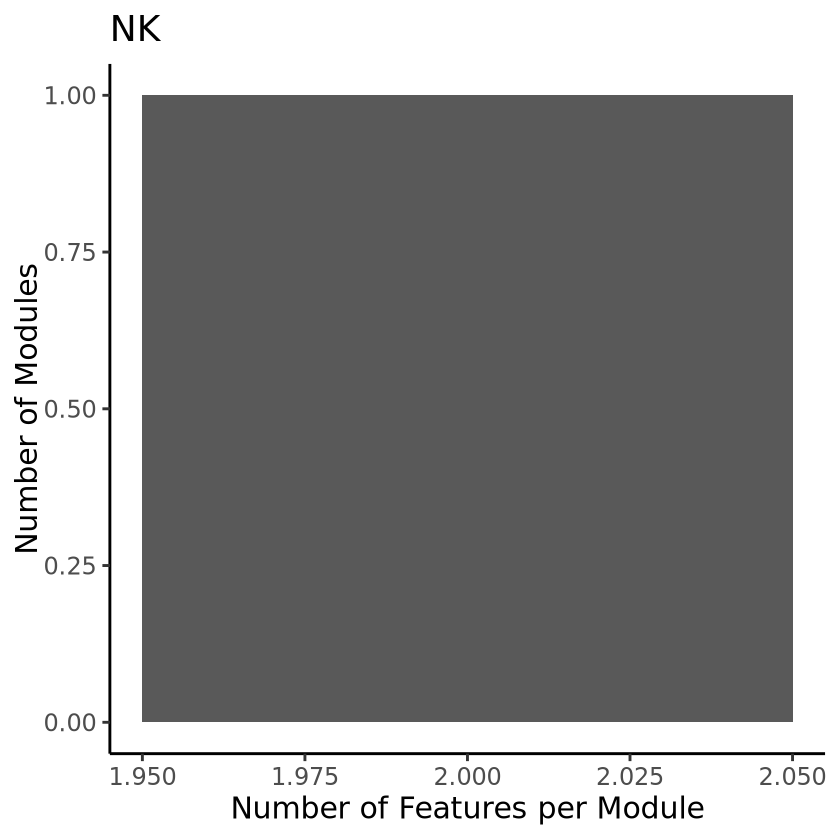

[1] "SKIPPING MULTI UPSET PLOT - NO MULTI FEATURE MODULES"
[1] "T"
          modality.2
modality.1 ATAC H3K27ac RNA
   ATAC      69       0   0
   H3K27ac    0       1   0
   RNA        4       0  25
[1] "Number of modules for T: 73"
[1] "Number of multi-QTL modules for T:2"
[1] "Number of singleton QTLs T:71"


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


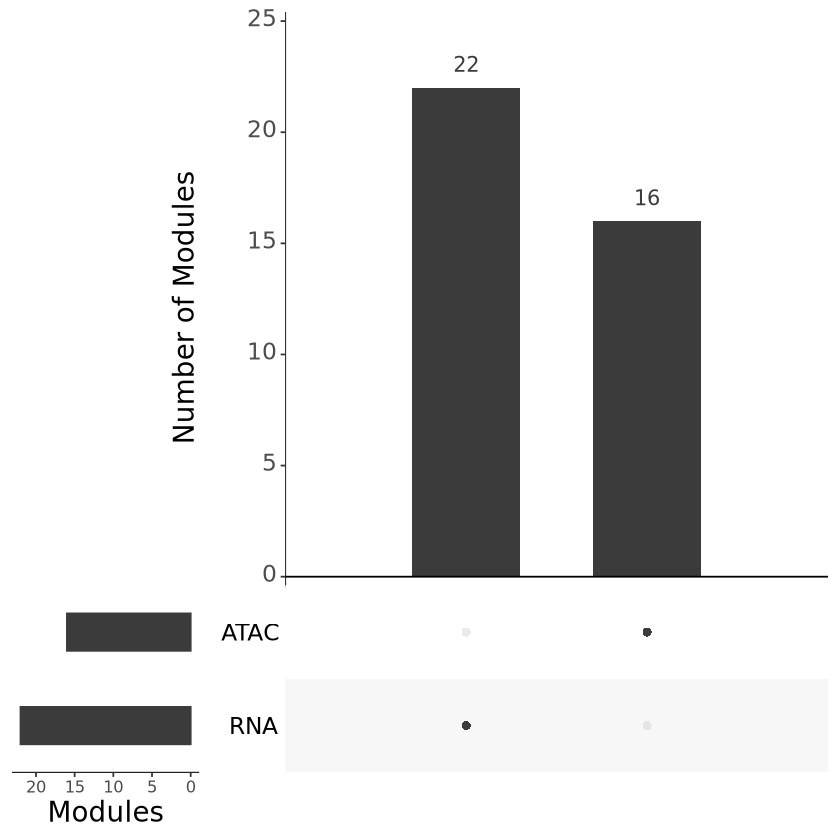

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


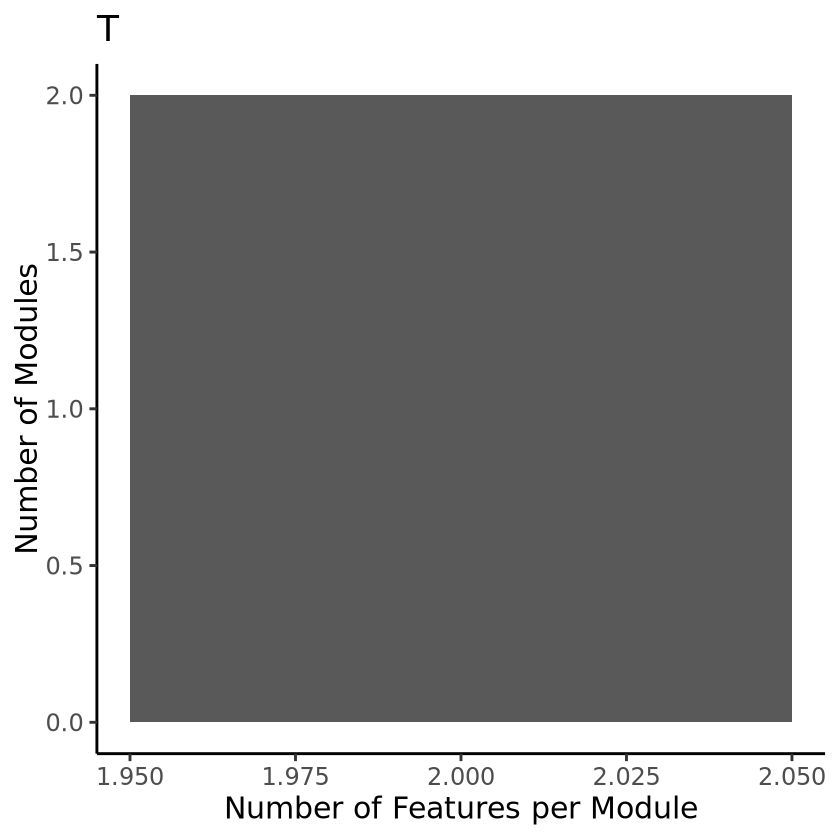

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


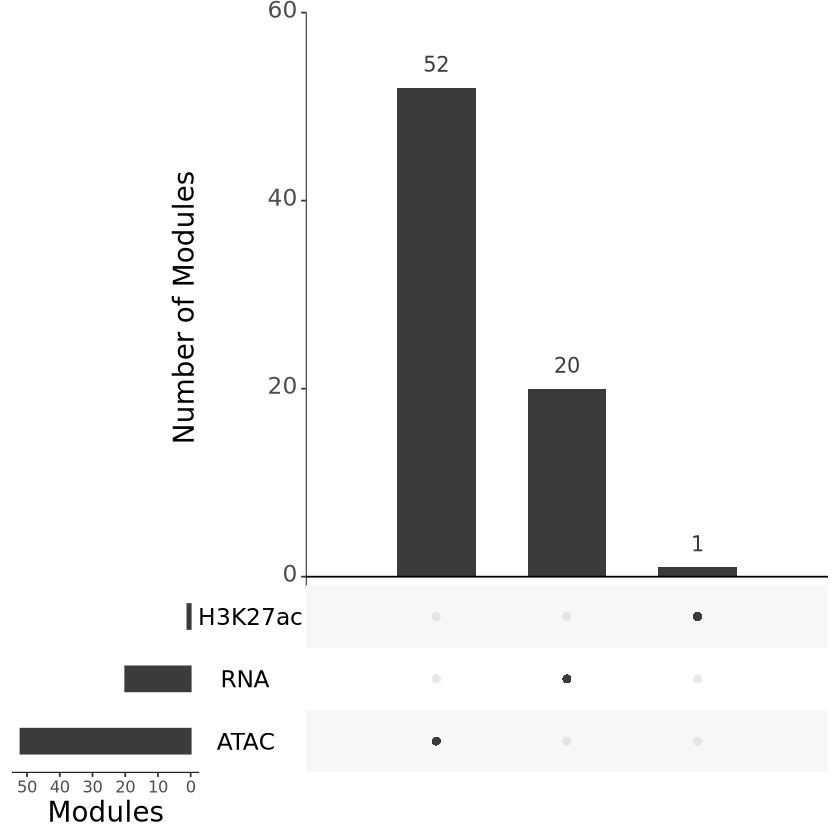

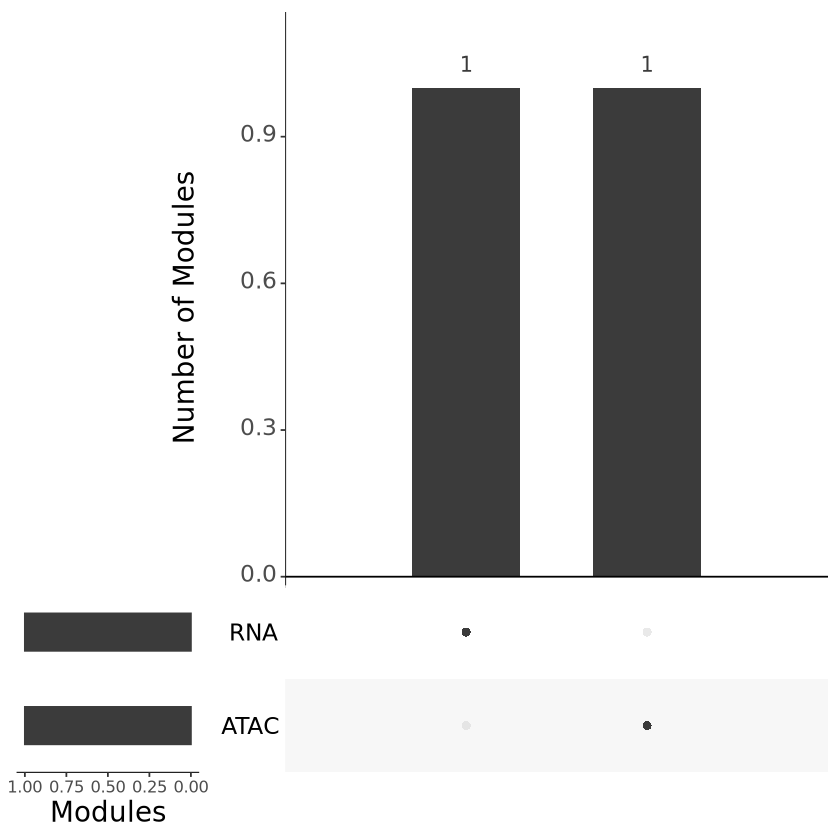

In [174]:
for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
#for (cell in c('B')) {
    print(cell)
    full.res <- data.frame()
    
    for (file in list.files(in.dir)[str_detect(list.files(in.dir), paste0('^',cell))]) {
        if(str_detect(file, 'Bulk')) {
            next
        }
        spec.res <- read.table(paste0(in.dir,file), header=T)
        spec.res <- filter(spec.res, PP.H4.abf > 0.8) %>%
        select(cell, modality.1, modality.2, PP.H4.abf, feature.1, feature.2)
        
        full.res <- rbind(full.res, spec.res)
    }
    
    print(table(select(full.res, modality.1, modality.2)))
    
    # Construct graph and cluster
    full.res$count <- 1
    graph <- graph_from_data_frame(select(full.res, feature.1, feature.2, count), 
                                   directed = FALSE, vertices = NULL)
    graph.cluster <- cluster_louvain(graph)
    
    #Split high modularity clusters
    modules.rec <- list()
    modules.rec <- subcluster_modules(modules.rec, graph, graph.cluster)
    print(paste0("Number of modules for ", cell, ": ", length(modules.rec)))
    
    # Step 4: Separate singletons and multi-QTL modules
    multi_qtl_modules <- modules.rec[sapply(modules.rec, vcount) > 1]
    singletons <- modules.rec[sapply(modules.rec, vcount) == 1]
    
    summary(singletons)
    summary(multi_qtl_modules)
    
    # Summary statistics
    print(paste0("Number of multi-QTL modules for ",cell,":", length(multi_qtl_modules)))
    print(paste0("Number of singleton QTLs ",cell,":", length(singletons)))
    
    if (length(multi_qtl_modules) == 0) {
        print('SKIPPING HISTOGRAM - NO MULTI FEATURE MODULES')
    } else {
        # Number of features per module historgram
        p1 <- ggplot(data.frame(feature.count=sapply(multi_qtl_modules, vcount)), aes(x=feature.count)) + 
            geom_histogram(bins=25) +
            theme_classic(base_size=18) +
            labs(y='Number of Modules', x='Number of Features per Module') + ggtitle(cell)
        print(p1)
        
        pdf(paste0('/nfs/lab/welison/Liver/Plots/','241211_WE_QTL_Module_Feauture_Histogram_',cell,'.pdf'))
        print(p1)
        dev.off()
    }
    
    # Construct upset plot data
    contains.ATAC <- logical()
    contains.RNA <- logical()
    contains.H3K27ac <- logical()
    contains.H3K27me3 <- logical()
    
    for (mod in modules.rec) {
        #print(i)
        mods.i <- filter(full.res, feature.1 %in% V(mod)$name & feature.2 %in% V(mod)$name) %>%
            select(modality.1, modality.2) %>%
            unlist() %>%
            unique()
        
        contains.ATAC <- c(contains.ATAC, any(str_detect(mods.i, 'ATAC')))
        contains.RNA <- c(contains.RNA, any(str_detect(mods.i, 'RNA')))
        contains.H3K27ac <- c(contains.H3K27ac, any(str_detect(mods.i, 'H3K27ac')))
        contains.H3K27me3 <- c(contains.H3K27me3, any(str_detect(mods.i, 'H3K27me3')))
    }
    
    counts <- data.frame(RNA=contains.RNA, ATAC=contains.ATAC, H3K27ac=contains.H3K27ac, H3K27me3=contains.H3K27me3)
    upset_data <- mutate_all(counts, as.numeric)
    
    pdf(paste0('/nfs/lab/welison/Liver/Plots/','241211_WE_QTL_Module_Upset_',cell,'.pdf'))
    print(upset(upset_data, order.by = "freq", text.scale = c(2,2,2,1.4,2,2), mainbar.y.label="Number of Modules", sets.x.label='Modules'))
    dev.off()
    
    print(upset(upset_data, order.by = "freq", text.scale = c(2,2,2,1.4,2,2), mainbar.y.label="Number of Modules", sets.x.label='Modules'))
    
    if (length(multi_qtl_modules) <= 1) {
        print('SKIPPING MULTI UPSET PLOT - NO MULTI FEATURE MODULES')
    } else {
            # Make upset plot data for multifeature qtl modules
        
        # Construct upset plot data
        contains.ATAC <- logical()
        contains.RNA <- logical()
        contains.H3K27ac <- logical()
        contains.H3K27me3 <- logical()
        
        for (mod in multi_qtl_modules) {
            mods.i <- filter(full.res, feature.1 %in% V(mod)$name & feature.2 %in% V(mod)$name) %>%
                select(modality.1, modality.2) %>%
                unlist() %>%
                unique()
            
            contains.ATAC <- c(contains.ATAC, any(str_detect(mods.i, 'ATAC')))
            contains.RNA <- c(contains.RNA, any(str_detect(mods.i, 'RNA')))
            contains.H3K27ac <- c(contains.H3K27ac, any(str_detect(mods.i, 'H3K27ac')))
            contains.H3K27me3 <- c(contains.H3K27me3, any(str_detect(mods.i, 'H3K27me3')))
        }
        
        counts <- data.frame(RNA=contains.RNA, ATAC=contains.ATAC, H3K27ac=contains.H3K27ac, H3K27me3=contains.H3K27me3)
        upset_data <- mutate_all(counts, as.numeric)
        
        pdf(paste0('/nfs/lab/welison/Liver/Plots/','241211_WE_QTL_Module_Upset_Multifeature_Modules_Only_',cell,'.pdf'))
        print(upset(upset_data, order.by = "freq", text.scale = c(2,2,2,1.4,2,2), mainbar.y.label="Number of Modules", sets.x.label='Modules'))
        dev.off()
        
        print(upset(upset_data, order.by = "freq", text.scale = c(2,2,2,1.4,2,2), mainbar.y.label="Number of Modules", sets.x.label='Modules'))
    }
    
    saveRDS(modules.rec, paste0(in.dir, 'graph_objects/241211_WE_',cell,'_qtl_modules_graph.RDS'))
    saveRDS(multi_qtl_modules, paste0(in.dir, 'graph_objects/241211_WE_',cell,'_multi_qtl_graph.RDS'))
    saveRDS(singletons, paste0(in.dir, 'graph_objects/241211_WE_',cell,'_singleton_qtl_graph.RDS'))
}

# Look for modules that overlap coloc signals

In [2]:
in.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/coloc.res/'
cell<- 'Hepatocytes'

In [3]:
modules.rec <- readRDS(paste0(in.dir, 'graph_objects/241211_WE_',cell,'_qtl_modules_graph.RDS'))
multi_qtl_modules <- readRDS(paste0(in.dir, 'graph_objects/241211_WE_',cell,'_multi_qtl_graph.RDS'))
singletons <- readRDS(paste0(in.dir, 'graph_objects/241211_WE_',cell,'_singleton_qtl_graph.RDS'))

In [4]:
coloc.results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/'
coloc.res.filt.graph.3 <- read.table(paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv'),
                                    header=T)
coloc.res.filt.graph.3

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
3137,6.809861e-28,1.723499e-26,6.380127e-04,0.015163181,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,chr15-89803942-89804242,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,chr19-4327651-4327951,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [5]:
length(multi_qtl_modules)

[1] 1232

In [6]:
module.assignment <- data.frame()

for (mod in 1:length(multi_qtl_modules)) {
    module.assignment <- rbind(module.assignment, data.frame(feature=unique(V(multi_qtl_modules[[mod]])$name), module=mod))
}

dim(module.assignment)
head(module.assignment)

[1] 5648    2

,feature,module
,<chr>,<int>
1,chr1-1005257-1005557,1
2,chr1-1420065-1420365,1
3,chr1-1692642-1692942,1
4,chr1-1746281-1746581,1
5,chr1-1891323-1891623,1
6,chr1-976057-976357,1


In [7]:
length(unique(module.assignment$feature))

[1] 5648

In [8]:
nrow(coloc.res.filt.graph.3)

[1] 62

In [9]:
merged_coloc <- left_join(module.assignment,coloc.res.filt.graph.3)

dim(merged_coloc)
head(merged_coloc)

sum(is.na(merged_coloc$PP.H4.abf))

Joining with `by = join_by(feature)`


[1] 5655   17

,feature,module,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1,chr1-1005257-1005557,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1-1420065-1420365,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1-1692642-1692942,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1-1746281-1746581,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1-1891323-1891623,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1-976057-976357,1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 5601

In [10]:
table(coloc.res.filt.graph.3$gwas.lead)


rs11621792  rs1497406  rs1547014   rs174535 rs28679728  rs3810367  rs4484649 
         3          4          7          1          1          1          1 
 rs4841133  rs4919741  rs7041363  rs7117339 rs72754571  rs7604422 
         4          3          1          1          1         34 

In [11]:
table(filter(merged_coloc, !is.na(PP.H4.abf))$gwas.lead)


rs11621792  rs1497406  rs1547014   rs174535  rs3810367  rs4484649  rs4841133 
         1          4          6          1          1          1          4 
 rs4919741  rs7041363 rs72754571  rs7604422 
         1          1          1         33 

In [12]:
filter(merged_coloc, !is.na(PP.H4.abf))

feature,module,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
chr1-16179136-16179436,25,2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
EPHA2,26,2921,3.793742e-06,4.743959e-04,8.686089e-04,0.107725977,0.8909272,Hepatocytes,RNA,rs7538833,1.494710e-06,16177886,rs1497406,1.458e-08,16178825,0.824
chr1-16189049-16189288,27,2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
chr1-16189980-16190280,27,2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
chr11-61820741-61821041,209,2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
chr12-52884847-52885147,278,3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
chr14-24402430-24402730,331,3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
chr15-89803942-89804242,399,3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
chr19-4327651-4327951,515,2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [13]:
i <- 25
multi_qtl_modules[[i]]
length(unique(names(V(multi_qtl_modules[[i]]))))
unique(names(V(multi_qtl_modules[[i]])))

IGRAPH 9b98409 UN-- 10 100 -- 
+ attr: name (v/c), count (e/n)
+ edges from 9b98409 (vertex names):
 [1] chr1-15282060-15282360--chr1-15282060-15282360
 [2] chr1-15282060-15282360--chr1-15285105-15285405
 [3] chr1-15282060-15282360--chr1-15285105-15285405
 [4] chr1-15285105-15285405--chr1-15285105-15285405
 [5] chr1-15282060-15282360--chr1-15596890-15597190
 [6] chr1-15282060-15282360--chr1-15596890-15597190
 [7] chr1-15285105-15285405--chr1-15596890-15597190
 [8] chr1-15285105-15285405--chr1-15596890-15597190
+ ... omitted several edges

[1] 10

[1] "chr1-15282060-15282360" "chr1-15285105-15285405" "chr1-15596890-15597190"
 [4] "chr1-15715777-15716077" "chr1-15825498-15825798" "chr1-15825919-15826219"
 [7] "chr1-15828946-15829246" "chr1-15994576-15994876" "chr1-16057474-16057774"
[10] "chr1-16179136-16179436"

In [14]:
full.res <- data.frame()
    
for (file in list.files(in.dir)[str_detect(list.files(in.dir), paste0('^',cell))]) {
    if(str_detect(file, 'Bulk')) {
        next
    }
    spec.res <- read.table(paste0(in.dir,file), header=T)
    spec.res <- filter(spec.res, PP.H4.abf > 0.8) %>%
    select(cell, modality.1, modality.2, PP.H4.abf, feature.1, feature.2)
    
    full.res <- rbind(full.res, spec.res)
}

In [15]:
contains.ATAC <- logical()
contains.RNA <- logical()
contains.H3K27ac <- logical()
contains.H3K27me3 <- logical()

for (mod in multi_qtl_modules) {
    mods.i <- filter(full.res, feature.1 %in% V(mod)$name & feature.2 %in% V(mod)$name) %>%
        select(modality.1, modality.2) %>%
        unlist() %>%
        unique()
    
    contains.ATAC <- c(contains.ATAC, any(str_detect(mods.i, 'ATAC')))
    contains.RNA <- c(contains.RNA, any(str_detect(mods.i, 'RNA')))
    contains.H3K27ac <- c(contains.H3K27ac, any(str_detect(mods.i, 'H3K27ac')))
    contains.H3K27me3 <- c(contains.H3K27me3, any(str_detect(mods.i, 'H3K27me3')))
}

counts <- data.frame(RNA=contains.RNA, ATAC=contains.ATAC, H3K27ac=contains.H3K27ac, H3K27me3=contains.H3K27me3)
upset_data <- mutate_all(counts, as.numeric)

In [16]:
counts

RNA,ATAC,H3K27ac,H3K27me3
<lgl>,<lgl>,<lgl>,<lgl>
FALSE,TRUE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE
TRUE,FALSE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE
TRUE,TRUE,FALSE,FALSE
FALSE,TRUE,FALSE,FALSE


In [17]:
counts.mod <- counts
counts.mod$mod.overlap <- ''
counts.mod$mod.overlap[counts.mod$RNA] <- paste0(counts.mod$mod.overlap[counts.mod$RNA], '-RNA')
counts.mod$mod.overlap[counts.mod$ATAC] <- paste0(counts.mod$mod.overlap[counts.mod$ATAC], '-ATAC')
counts.mod$mod.overlap[counts.mod$H3K27ac] <- paste0(counts.mod$mod.overlap[counts.mod$H3K27ac], '-H3K27ac')
counts.mod$mod.overlap[counts.mod$H3K27me3] <- paste0(counts.mod$mod.overlap[counts.mod$H3K27me3], '-H3K27me3')
counts.mod$mod.overlap <- str_remove(counts.mod$mod.overlap, '-')

counts.mod <- group_by(counts.mod, mod.overlap) %>%
                summarise(n=n()) %>%
                arrange(desc(n)) %>%
                mutate(mod.overlap=factor(mod.overlap, levels=unique(mod.overlap)))

counts.mod

mod.overlap,n
<fct>,<int>
ATAC,927
RNA,111
ATAC-H3K27ac,68
RNA-ATAC,38
H3K27ac,30
RNA-H3K27ac,15
ATAC-H3K27me3,14
H3K27me3,12
RNA-H3K27ac-H3K27me3,7


In [18]:
my_colors <- c(
  "RNA" = "#F8766D",
  "ATAC" = "#7CAE00",
  "H3K27ac" = "#00BFC4",
  "H3K27me3" = "#C77CFF",
  "RNA-ATAC" = "#BF9D37",
  "RNA-H3K27ac" = "#95C2A6",
  "RNA-H3K27me3" = "#D07592",
  "ATAC-H3K27ac" = "#57B07F",
  "ATAC-H3K27me3" = "#92A44C",
  "H3K27ac-H3K27me3" = "#8C91C0",
  "RNA-ATAC-H3K27ac" = "#B88346",
  "RNA-ATAC-H3K27me3" = "#AB63B8",
  "RNA-H3K27ac-H3K27me3" = "#7E91A9",
  "ATAC-H3K27ac-H3K27me3" = "#5DA58D",
  "RNA-ATAC-H3K27ac-H3K27me3" = "#978B7E"
)

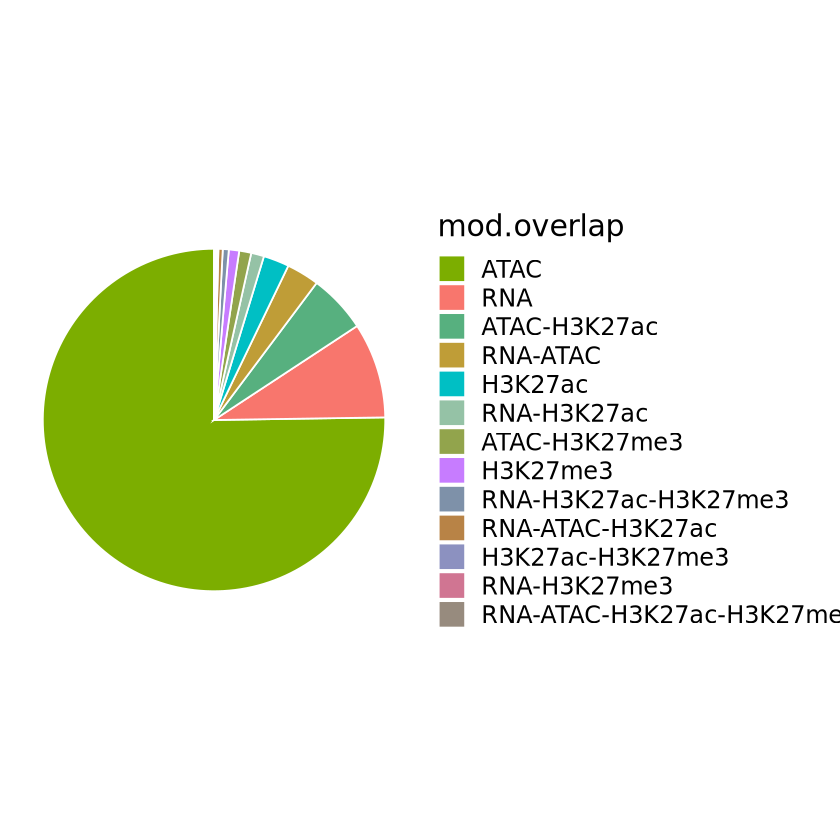

In [19]:
# Basic piechart
ggplot(counts.mod, aes(x="", y=n, fill=mod.overlap)) +
  geom_bar(stat="identity", width=1, color="white") +
  coord_polar("y", start=0) +
  theme_void(base_size=18) + 
  #theme(legend.position="none") #+
  
  #geom_text(aes(y = ypos, label = group), color = "white", size=6) +
  scale_fill_manual(values=my_colors)

In [20]:
pie.data <- data.frame()

for (cell in c('Hepatocytes','Cholangiocyte','Endothelial','HSC','Myeloid','T','NK')) {
    full.res <- data.frame()
    multi_qtl_modules <- readRDS(paste0(in.dir, 'graph_objects/241211_WE_',cell,'_multi_qtl_graph.RDS'))
    
    for (file in list.files(in.dir)[str_detect(list.files(in.dir), paste0('^',cell))]) {
        if(str_detect(file, 'Bulk')) {
            next
        }
        spec.res <- read.table(paste0(in.dir,file), header=T)
        spec.res <- filter(spec.res, PP.H4.abf > 0.8) %>%
        select(cell, modality.1, modality.2, PP.H4.abf, feature.1, feature.2)
        
        full.res <- rbind(full.res, spec.res)
    }
    
    contains.ATAC <- logical()
    contains.RNA <- logical()
    contains.H3K27ac <- logical()
    contains.H3K27me3 <- logical()
    
    for (mod in multi_qtl_modules) {
        mods.i <- filter(full.res, feature.1 %in% V(mod)$name & feature.2 %in% V(mod)$name) %>%
            select(modality.1, modality.2) %>%
            unlist() %>%
            unique()
        
        contains.ATAC <- c(contains.ATAC, any(str_detect(mods.i, 'ATAC')))
        contains.RNA <- c(contains.RNA, any(str_detect(mods.i, 'RNA')))
        contains.H3K27ac <- c(contains.H3K27ac, any(str_detect(mods.i, 'H3K27ac')))
        contains.H3K27me3 <- c(contains.H3K27me3, any(str_detect(mods.i, 'H3K27me3')))
    }
    
    counts <- data.frame(RNA=contains.RNA, ATAC=contains.ATAC, H3K27ac=contains.H3K27ac, H3K27me3=contains.H3K27me3)
    
    counts.mod <- counts
    counts.mod$mod.overlap <- ''
    counts.mod$mod.overlap[counts.mod$RNA] <- paste0(counts.mod$mod.overlap[counts.mod$RNA], '-RNA')
    counts.mod$mod.overlap[counts.mod$ATAC] <- paste0(counts.mod$mod.overlap[counts.mod$ATAC], '-ATAC')
    counts.mod$mod.overlap[counts.mod$H3K27ac] <- paste0(counts.mod$mod.overlap[counts.mod$H3K27ac], '-H3K27ac')
    counts.mod$mod.overlap[counts.mod$H3K27me3] <- paste0(counts.mod$mod.overlap[counts.mod$H3K27me3], '-H3K27me3')
    counts.mod$mod.overlap <- str_remove(counts.mod$mod.overlap, '-')
    
    counts.mod <- group_by(counts.mod, mod.overlap) %>%
                    summarise(n=n()) %>%
                    arrange(desc(n)) %>%
                    mutate(mod.overlap=factor(mod.overlap, levels=unique(mod.overlap)))
    
    counts.mod$cell <- cell
    pie.data <- rbind(pie.data, counts.mod)
}

dim(pie.data)
head(pie.data)

[1] 32  3

mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC,927,Hepatocytes
RNA,111,Hepatocytes
ATAC-H3K27ac,68,Hepatocytes
RNA-ATAC,38,Hepatocytes
H3K27ac,30,Hepatocytes
RNA-H3K27ac,15,Hepatocytes


In [21]:
dim(pie.data)
head(pie.data)
tail(pie.data)

[1] 32  3

mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC,927,Hepatocytes
RNA,111,Hepatocytes
ATAC-H3K27ac,68,Hepatocytes
RNA-ATAC,38,Hepatocytes
H3K27ac,30,Hepatocytes
RNA-H3K27ac,15,Hepatocytes


mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC-H3K27ac,6,Myeloid
H3K27me3,1,Myeloid
RNA-H3K27ac,1,Myeloid
ATAC,1,T
RNA,1,T
RNA,1,NK


In [22]:
my_colors <- c(
  "RNA" = "#F8766D",
  "ATAC" = "#7CAE00",
  "H3K27ac" = "#00BFC4",
  "H3K27me3" = "#C77CFF",
  "RNA-ATAC" = "#BF9D37",
  "RNA-H3K27ac" = "#95C2A6",
  "RNA-H3K27me3" = "#D07592",
  "ATAC-H3K27ac" = "#57B07F",
  "ATAC-H3K27me3" = "#92A44C",
  "H3K27ac-H3K27me3" = "#8C91C0",
  "RNA-ATAC-H3K27ac" = "#B88346",
  "RNA-ATAC-H3K27me3" = "#AB63B8",
  "RNA-H3K27ac-H3K27me3" = "#7E91A9",
  "ATAC-H3K27ac-H3K27me3" = "#5DA58D",
  "RNA-ATAC-H3K27ac-H3K27me3" = "#978B7E"
)

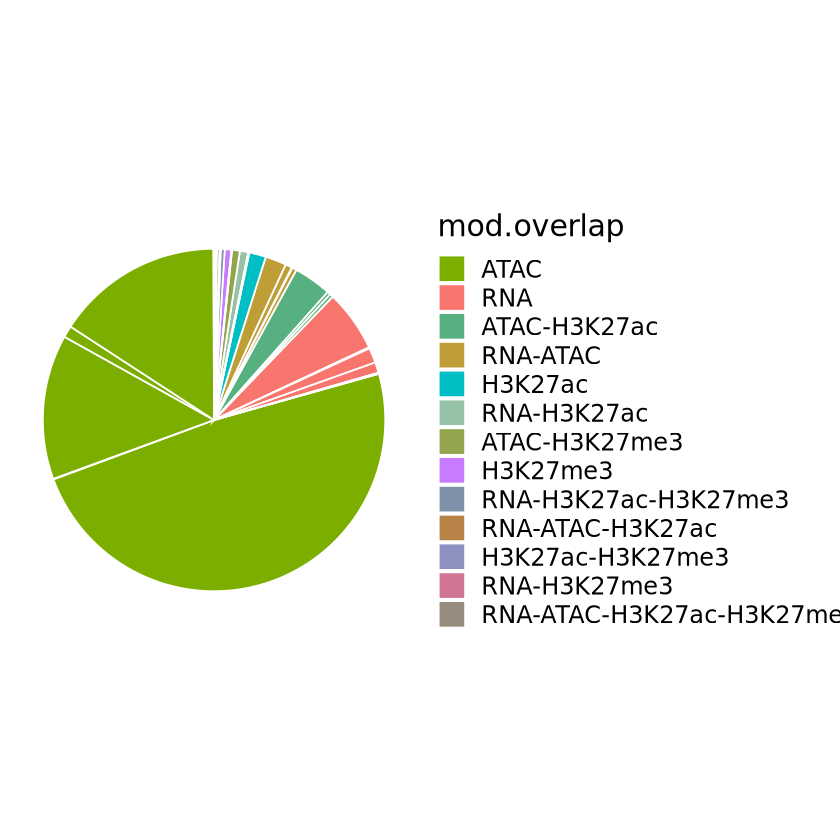

In [23]:
# Basic piechart
ggplot(pie.data, aes(x="", y=n, fill=mod.overlap)) +
  geom_bar(stat="identity", width=1, color="white") +
  coord_polar("y", start=0) +
  theme_void(base_size=18) + 
  #theme(legend.position="none") #+
  
  #geom_text(aes(y = ypos, label = group), color = "white", size=6) +
  scale_fill_manual(values=my_colors)

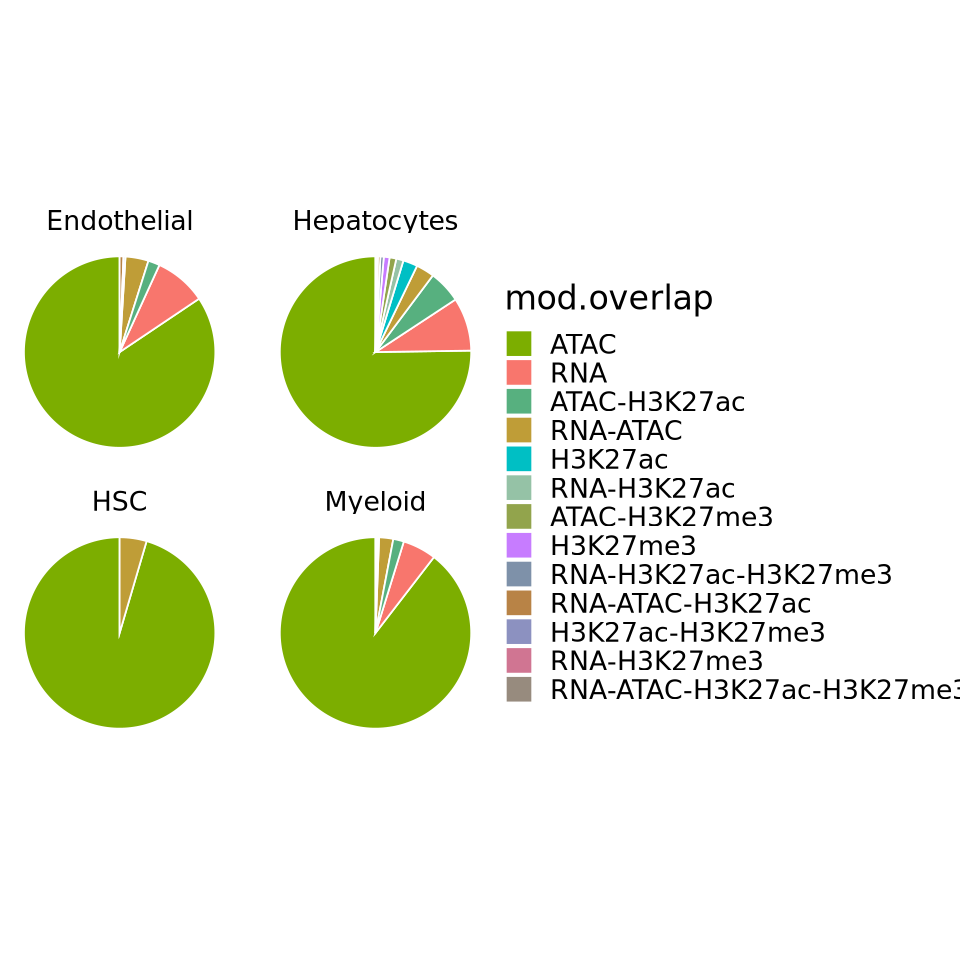

In [24]:
# Basic piechart
options(repr.plot.width=8, repr.plot.height=8)
p1 <- filter(pie.data, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          coord_polar("y", start=0) +
          theme_void(base_size=20) + 
          #theme(legend.position="none") #+
          
          #geom_text(aes(y = ypos, label = group), color = "white", size=6) +
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y')

p1

#pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_pie.pdf', width=8, height=8)
#p1
#dev.off()

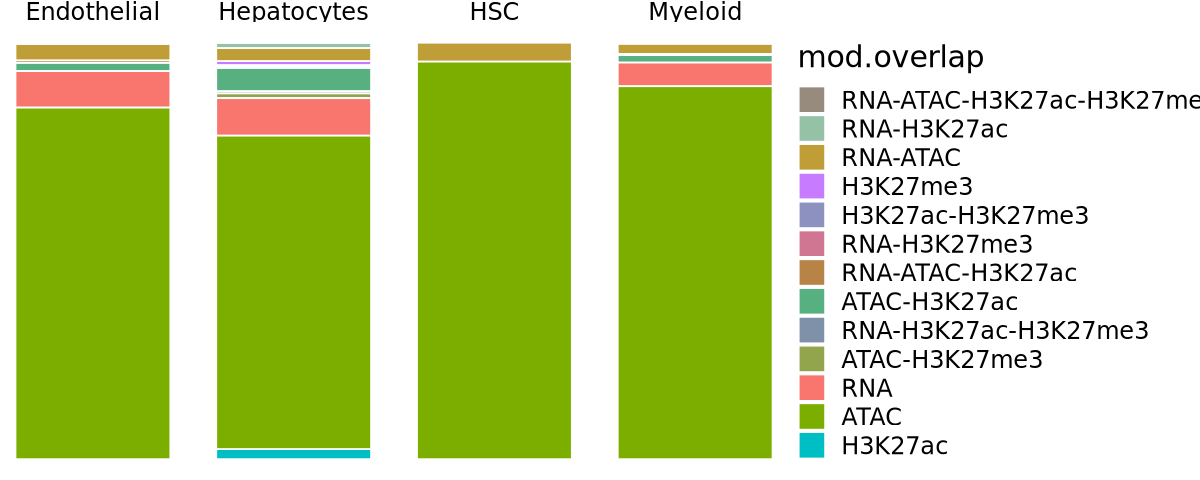

In [25]:
# Basic piechart
options(repr.plot.width=10, repr.plot.height=4)
p1 <- filter(pie.data, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        arrange(n) %>%
        mutate(mod.overlap=factor(mod.overlap, unique(mod.overlap))) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          theme_void(base_size=18) + 
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y', ncol=4)


p1

#pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_bar.pdf', width=10, height=4)
#p1
#dev.off()

In [26]:
my_colors <- c(
  "RNA" = "#F8766D",
  "ATAC" = "#7CAE00",
  "H3K27ac" = "#00BFC4",
  "H3K27me3" = "#C77CFF",
  "RNA-ATAC" = "#BF9D37",
  "RNA-H3K27ac" = "#95C2A6",
  "RNA-H3K27me3" = "#D07592",
  "ATAC-H3K27ac" = "#57B07F",
  "ATAC-H3K27me3" = "#92A44C",
  "H3K27ac-H3K27me3" = "#8C91C0",
  "RNA-ATAC-H3K27ac" = "#B88346",
  "RNA-ATAC-H3K27me3" = "#AB63B8",
  "RNA-H3K27ac-H3K27me3" = "#7E91A9",
  "ATAC-H3K27ac-H3K27me3" = "#5DA58D",
  "RNA-ATAC-H3K27ac-H3K27me3" = "#978B7E",
  "Three or more" = "#978B7E" 
)

In [27]:
head(pie.data)

mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC,927,Hepatocytes
RNA,111,Hepatocytes
ATAC-H3K27ac,68,Hepatocytes
RNA-ATAC,38,Hepatocytes
H3K27ac,30,Hepatocytes
RNA-H3K27ac,15,Hepatocytes


In [28]:
pie.data

mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC,927,Hepatocytes
RNA,111,Hepatocytes
ATAC-H3K27ac,68,Hepatocytes
RNA-ATAC,38,Hepatocytes
H3K27ac,30,Hepatocytes
RNA-H3K27ac,15,Hepatocytes
ATAC-H3K27me3,14,Hepatocytes
H3K27me3,12,Hepatocytes
RNA-H3K27ac-H3K27me3,7,Hepatocytes


In [29]:
table(pie.data$mod.overlap)

pie.data.merge <- pie.data %>%
    mutate(mod.overlap=as.character(mod.overlap)) %>%
    mutate(mod.overlap=ifelse(str_detect(mod.overlap, '-[:alnum:]*-'), 'Three or more', mod.overlap)) %>%
    mutate(mod.overlap=factor(mod.overlap, levels=c(unique(mod.overlap[mod.overlap != 'Three or more']), 'Three or more'))) %>%
    mutate(cell)

table(pie.data.merge$mod.overlap)


                     ATAC                       RNA              ATAC-H3K27ac 
                        6                         6                         3 
                 RNA-ATAC                   H3K27ac               RNA-H3K27ac 
                        4                         1                         3 
            ATAC-H3K27me3                  H3K27me3      RNA-H3K27ac-H3K27me3 
                        1                         2                         1 
         RNA-ATAC-H3K27ac          H3K27ac-H3K27me3              RNA-H3K27me3 
                        2                         1                         1 
RNA-ATAC-H3K27ac-H3K27me3 
                        1 


            ATAC              RNA     ATAC-H3K27ac         RNA-ATAC 
               6                6                3                4 
         H3K27ac      RNA-H3K27ac    ATAC-H3K27me3         H3K27me3 
               1                3                1                2 
H3K27ac-H3K27me3     RNA-H3K27me3    Three or more 
               1                1                4 

pdf 
  2

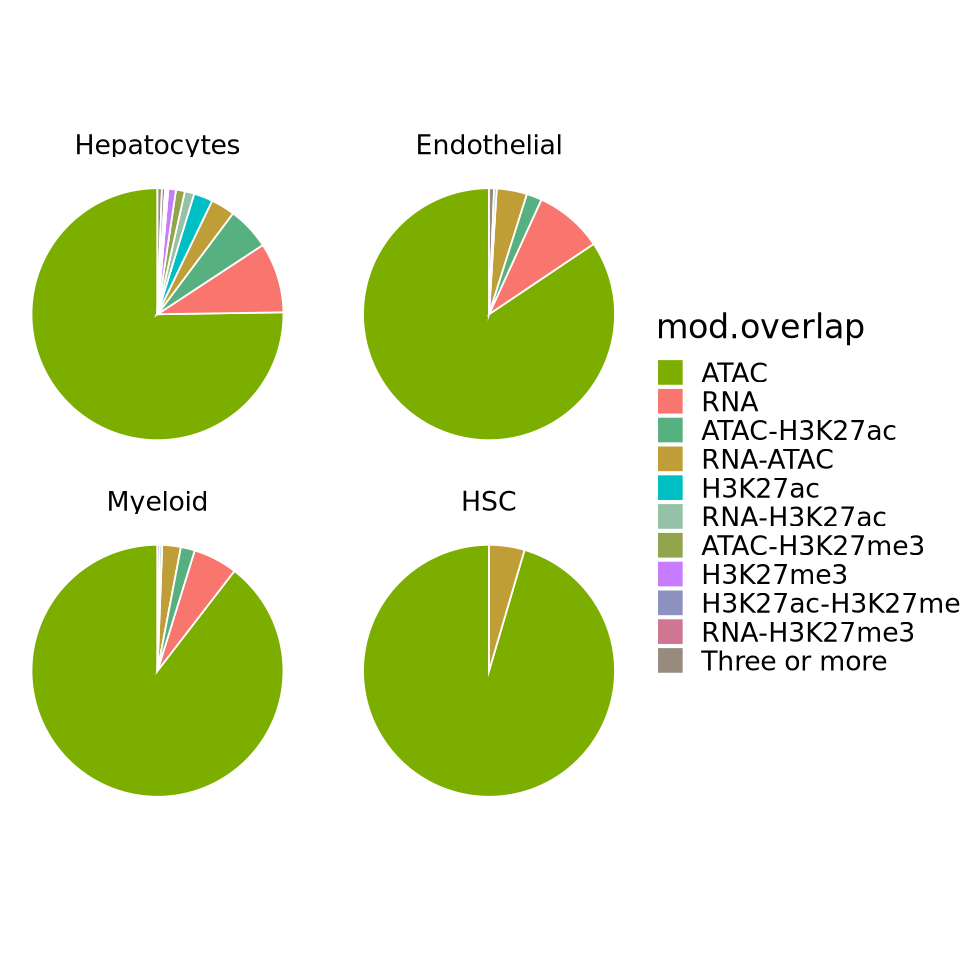

In [30]:
# Basic piechart
options(repr.plot.width=8, repr.plot.height=8)
p1 <- filter(pie.data.merge, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          coord_polar("y", start=0) +
          theme_void(base_size=20) + 
          #theme(legend.position="none") #+
          
          #geom_text(aes(y = ypos, label = group), color = "white", size=6) +
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y')

p1

pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_pie.pdf', width=8, height=8)
p1
dev.off()

pdf 
  2

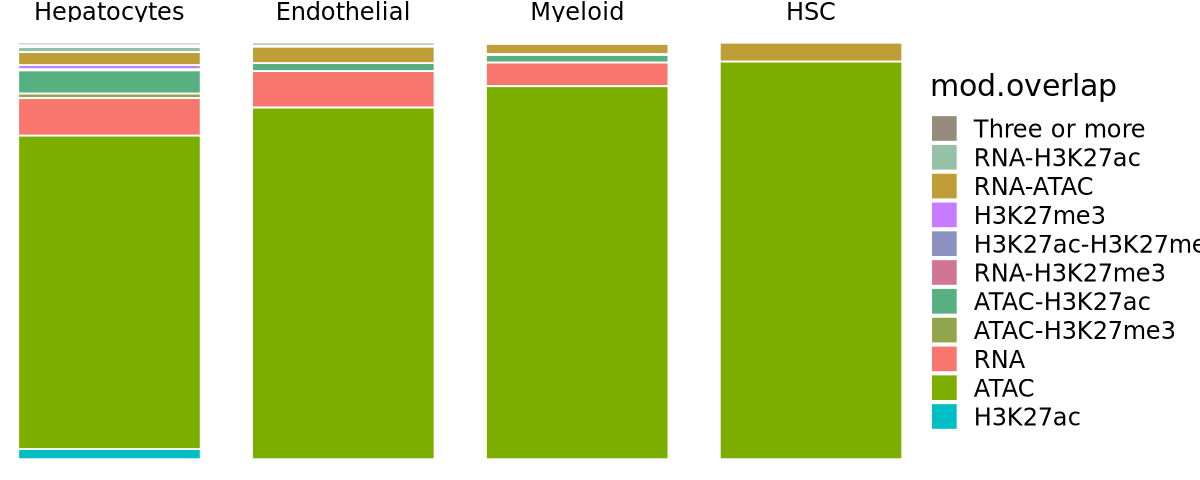

In [31]:
# Basic piechart
options(repr.plot.width=10, repr.plot.height=4)
p1 <- filter(pie.data.merge, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        arrange(n) %>%
        mutate(mod.overlap=factor(mod.overlap, unique(mod.overlap))) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          theme_void(base_size=18) + 
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y', ncol=4)


p1

pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_bar.pdf', width=10, height=4)
p1
dev.off()

In [33]:
table(pie.data$mod.overlap)

pie.data.merge <- pie.data %>%
    mutate(mod.overlap=as.character(mod.overlap)) %>%
    mutate(mod.overlap=ifelse(str_detect(mod.overlap, '-[:alnum:]*-'), 'Three or more', mod.overlap)) %>%
    mutate(mod.overlap=factor(mod.overlap, levels=c(unique(mod.overlap[mod.overlap != 'Three or more']), 'Three or more'))) %>%
    mutate(cell)

table(pie.data.merge$mod.overlap)


                     ATAC                       RNA              ATAC-H3K27ac 
                        6                         6                         3 
                 RNA-ATAC                   H3K27ac               RNA-H3K27ac 
                        4                         1                         3 
            ATAC-H3K27me3                  H3K27me3      RNA-H3K27ac-H3K27me3 
                        1                         2                         1 
         RNA-ATAC-H3K27ac          H3K27ac-H3K27me3              RNA-H3K27me3 
                        2                         1                         1 
RNA-ATAC-H3K27ac-H3K27me3 
                        1 


            ATAC              RNA     ATAC-H3K27ac         RNA-ATAC 
               6                6                3                4 
         H3K27ac      RNA-H3K27ac    ATAC-H3K27me3         H3K27me3 
               1                3                1                2 
H3K27ac-H3K27me3     RNA-H3K27me3    Three or more 
               1                1                4 

In [37]:
table(pie.data$mod.overlap)

pie.data.merge <- pie.data %>%
    mutate(mod.overlap=as.character(mod.overlap)) %>%
    mutate(mod.overlap=ifelse(str_detect(mod.overlap, '-H3K27me3'), 'Other', 
                              ifelse(str_detect(mod.overlap, '-[:alnum:]*-'), 'Other',
                              ifelse(str_detect(mod.overlap, 'RNA-H3K27ac'), 'Other', mod.overlap)))) %>%
    mutate(mod.overlap=factor(mod.overlap, levels=c(unique(mod.overlap[mod.overlap != 'Other']), 'Other'))) %>%
    mutate(cell)

table(pie.data.merge$mod.overlap)


                     ATAC                       RNA              ATAC-H3K27ac 
                        6                         6                         3 
                 RNA-ATAC                   H3K27ac               RNA-H3K27ac 
                        4                         1                         3 
            ATAC-H3K27me3                  H3K27me3      RNA-H3K27ac-H3K27me3 
                        1                         2                         1 
         RNA-ATAC-H3K27ac          H3K27ac-H3K27me3              RNA-H3K27me3 
                        2                         1                         1 
RNA-ATAC-H3K27ac-H3K27me3 
                        1 


        ATAC          RNA ATAC-H3K27ac     RNA-ATAC      H3K27ac     H3K27me3 
           6            6            3            4            1            2 
       Other 
          10 

In [40]:
levels(pie.data.merge$mod.overlap)

[1] "ATAC"         "RNA"          "ATAC-H3K27ac" "RNA-ATAC"     "H3K27ac"     
[6] "H3K27me3"     "Other"

In [41]:
my_colors <- c(
  "RNA" = "#F8766D",
  "ATAC" = "#7CAE00",
  "H3K27ac" = "#00BFC4",
  "H3K27me3" = "#C77CFF",
  "RNA-ATAC" = "#BF9D37",
  "RNA-H3K27ac" = "#95C2A6",
  "RNA-H3K27me3" = "#D07592",
  "ATAC-H3K27ac" = "#57B07F",
  "ATAC-H3K27me3" = "#92A44C",
  "H3K27ac-H3K27me3" = "#8C91C0",
  "RNA-ATAC-H3K27ac" = "#B88346",
  "RNA-ATAC-H3K27me3" = "#AB63B8",
  "RNA-H3K27ac-H3K27me3" = "#7E91A9",
  "ATAC-H3K27ac-H3K27me3" = "#5DA58D",
  "RNA-ATAC-H3K27ac-H3K27me3" = "#978B7E",
  "Three or more" = "#978B7E" ,
  "Other" = "#978B7E"
)

pdf 
  2

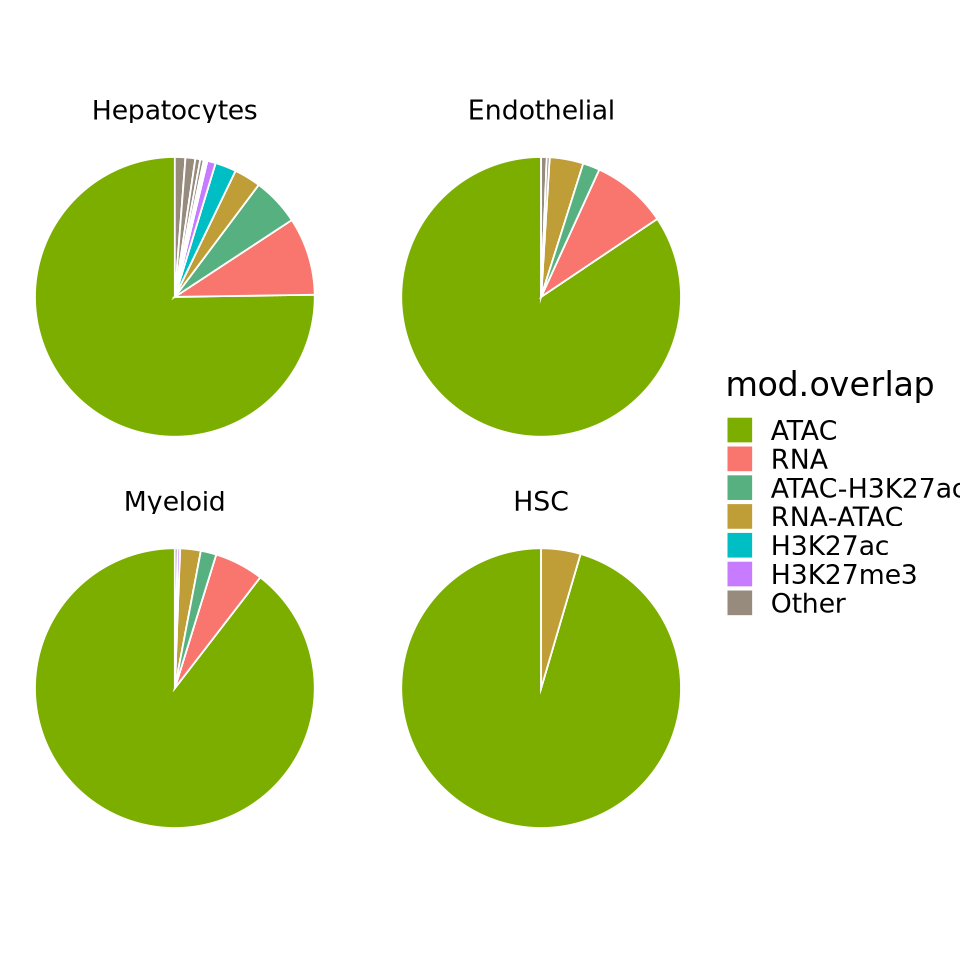

In [42]:
# Basic piechart
options(repr.plot.width=8, repr.plot.height=8)
p1 <- filter(pie.data.merge, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          coord_polar("y", start=0) +
          theme_void(base_size=20) + 
          #theme(legend.position="none") #+
          
          #geom_text(aes(y = ypos, label = group), color = "white", size=6) +
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y')

p1

pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_pie_v2.pdf', width=8, height=8)
p1
dev.off()

In [43]:
head(pie.data.merge)

mod.overlap,n,cell
<fct>,<int>,<chr>
ATAC,927,Hepatocytes
RNA,111,Hepatocytes
ATAC-H3K27ac,68,Hepatocytes
RNA-ATAC,38,Hepatocytes
H3K27ac,30,Hepatocytes
Other,15,Hepatocytes


In [48]:
pie.data.merge.subset <- pie.data.merge %>%
    group_by(cell, mod.overlap) %>%
    summarise(n=sum(n))

`summarise()` has grouped output by 'cell'. You can override using the `.groups` argument.


pdf 
  2

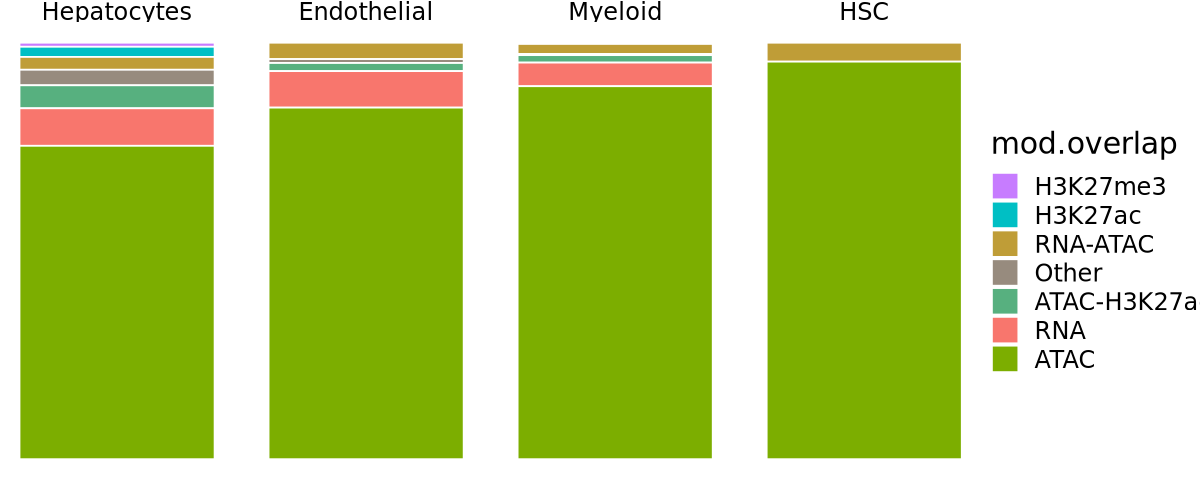

In [49]:
# Basic piechart
options(repr.plot.width=10, repr.plot.height=4)
p1 <- filter(pie.data.merge.subset, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        arrange(n) %>%
        mutate(mod.overlap=factor(mod.overlap, unique(mod.overlap))) %>%
        ggplot(aes(x="", y=n, fill=mod.overlap)) +
          geom_bar(stat="identity", width=1, color="white") +
          theme_void(base_size=18) + 
          scale_fill_manual(values=my_colors) +
          facet_wrap(. ~ cell, scales = 'free_y', ncol=4)


p1

pdf('/nfs/lab/welison/Liver/Plots/241221_qtl_module_overlap_bar_2.pdf', width=10, height=4)
p1
dev.off()

In [55]:
pie.data.merge.subset.prop <- filter(pie.data.merge.subset, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        arrange(n) %>%
        mutate(mod.overlap=factor(mod.overlap, unique(mod.overlap)))

pie.data.merge.subset.prop <- group_by(pie.data.merge.subset.prop, cell) %>%
                            summarise(sum=sum(n)) %>%
                            inner_join(pie.data.merge.subset.prop) %>%
                            mutate(prop=n/sum)

pie.data.merge.subset.prop

Joining with `by = join_by(cell)`


cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
Hepatocytes,1232,H3K27me3,12,0.009740260
Hepatocytes,1232,H3K27ac,30,0.024350649
Hepatocytes,1232,RNA-ATAC,38,0.030844156
Hepatocytes,1232,Other,46,0.037337662
Hepatocytes,1232,ATAC-H3K27ac,68,0.055194805
Hepatocytes,1232,RNA,111,0.090097403
Hepatocytes,1232,ATAC,927,0.752435065
Endothelial,308,Other,3,0.009740260
Endothelial,308,ATAC-H3K27ac,6,0.019480519


In [56]:
filter(pie.data.merge.subset.prop, cell=='Hepatocytes')
filter(pie.data.merge.subset.prop, cell=='HSC')
filter(pie.data.merge.subset.prop, cell=='Endothelial')
filter(pie.data.merge.subset.prop, cell=='Myeloid')

cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
Hepatocytes,1232,H3K27me3,12,0.00974026
Hepatocytes,1232,H3K27ac,30,0.02435065
Hepatocytes,1232,RNA-ATAC,38,0.03084416
Hepatocytes,1232,Other,46,0.03733766
Hepatocytes,1232,ATAC-H3K27ac,68,0.05519481
Hepatocytes,1232,RNA,111,0.09009740
Hepatocytes,1232,ATAC,927,0.75243506


cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
HSC,22,RNA-ATAC,1,0.04545455
HSC,22,ATAC,21,0.95454545


cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
Endothelial,308,Other,3,0.00974026
Endothelial,308,ATAC-H3K27ac,6,0.01948052
Endothelial,308,RNA-ATAC,12,0.03896104
Endothelial,308,RNA,27,0.08766234
Endothelial,308,ATAC,260,0.84415584


cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
Myeloid,335,H3K27me3,1,0.002985075
Myeloid,335,Other,1,0.002985075
Myeloid,335,ATAC-H3K27ac,6,0.017910448
Myeloid,335,RNA-ATAC,8,0.023880597
Myeloid,335,RNA,19,0.056716418
Myeloid,335,ATAC,300,0.895522388


In [57]:
write.table(pie.data.merge.subset.prop, '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/coloc.res/241226_WE_module_overlap_plotting_proportions.tsv',
           sep='\t', col.names=T, row.names=T, quote=F)

In [60]:
pie.data.prop <- filter(pie.data, cell %in% c('Hepatocytes','Endothelial','HSC','Myeloid')) %>%
        mutate(cell=factor(cell, c('Hepatocytes','Endothelial','Myeloid','HSC'))) %>%
        arrange(n) %>%
        mutate(mod.overlap=factor(mod.overlap, unique(mod.overlap)))

pie.data.prop <- group_by(pie.data.prop, cell) %>%
                            summarise(sum=sum(n)) %>%
                            inner_join(pie.data.prop) %>%
                            mutate(prop=n/sum)

pie.data.prop

Joining with `by = join_by(cell)`


cell,sum,mod.overlap,n,prop
<fct>,<int>,<fct>,<int>,<dbl>
Hepatocytes,1232,RNA-ATAC-H3K27ac-H3K27me3,1,0.0008116883
Hepatocytes,1232,H3K27ac-H3K27me3,2,0.0016233766
Hepatocytes,1232,RNA-H3K27me3,2,0.0016233766
Hepatocytes,1232,RNA-ATAC-H3K27ac,5,0.0040584416
Hepatocytes,1232,RNA-H3K27ac-H3K27me3,7,0.0056818182
Hepatocytes,1232,H3K27me3,12,0.0097402597
Hepatocytes,1232,ATAC-H3K27me3,14,0.0113636364
Hepatocytes,1232,RNA-H3K27ac,15,0.0121753247
Hepatocytes,1232,H3K27ac,30,0.0243506494


In [61]:
write.table(pie.data.merge.subset.prop, '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/coloc.res/241226_WE_module_overlap_plotting_proportions_no_group_collapse.tsv',
           sep='\t', col.names=T, row.names=T, quote=F)

# Make beds to intersect with GRN

In [72]:
modalities <- c('RNA','ATAC','H3K27ac','H3K27me3')

for (cell in c('B','T','NK','Hepatocytes','Endothelial','Myeloid','HSC','Cholangiocyte','Bulk')) {  
    message(cell)
    
    ### Create GRanges for each modality
    for (mod in modalities) {
        message(mod)
        # Get modality specific paths
        if (mod == 'RNA') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/counts/',
                                 cell,'_perdonor.RNA.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        } else if (mod == 'ATAC') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/counts/',
                                 cell,'_perdonor.ATAC.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/',
                                 cell,'.cis_qtl.txt.gz')
        } else if (mod == 'H3K27ac') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/counts/',
                                 cell,'_perdonor.H3K27ac.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        }else if (mod == 'H3K27me3') {
            count.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/counts/',
                                 cell,'_perdonor.H3K27me3.INT.bed')
            feature.res.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
        }
        
        ### Read in data for the first modality and add columns
        counts <- read.table(count.path)
        counts$modality <- mod
        counts$cell <- cell
        
        qtl.feature.res <- read.table(feature.res.path, header=T)
        counts <- left_join(counts, select(qtl.feature.res, phenotype_id, variant_id), by=join_by(V4==phenotype_id))
        qtl.feature.res <- filter(qtl.feature.res, qval < 0.05)
        
        counts$sig <- FALSE
        if (nrow(qtl.feature.res) > 0) {
            counts[counts$V4 %in% qtl.feature.res$phenotype_id,]$sig <- TRUE
        }
        
        message(nrow(qtl.feature.res))
        message(sum(counts$sig))
        message(nrow(counts))
        
        ### Construct GRanges object
        gr <- GRanges(seqnames = counts[,1], ranges = IRanges(start = as.numeric(counts[,2]), end = as.numeric(counts[,3])),
                        mcols=select(counts, modality, feature=V4, cell, sig, variant_id))
    
        gc()
        
        write.table(data.frame(gr), paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/',
                                   mod,'.',cell,'.feature.bed'), col.names=F, row.names=F, quote=F, sep='\t')
        write.table(filter(data.frame(gr), mcols.sig), paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/',
                                   mod,'.',cell,'.feature.fdr.bed'), col.names=F, row.names=F, quote=F, sep='\t')
    }
} 

B

RNA

7

7

6932

ATAC

6

6

20801

H3K27ac

0

0

13285

H3K27me3

0

0

1247

T

RNA

21

21

7028

ATAC

54

54

25867

H3K27ac

1

1

16392

H3K27me3

0

0

14085

NK

RNA

23

23

6234

ATAC

16

16

21681

H3K27ac

0

0

9386

H3K27me3

0

0

2634

Hepatocytes

RNA

871

871

20235

ATAC

6106

6106

549326

H3K27ac

370

370

262385

H3K27me3

388

388

428811

Endothelial

RNA

293

293

15465

ATAC

1855

1855

147882

H3K27ac

33

33

105716

H3K27me3

0

0

116452

Myeloid

RNA

284

284

13734

ATAC

2047

2047

170862

H3K27ac

14

14

112802

H3K27me3

2

2

268971

HSC

RNA

94

94

13657

ATAC

443

443

115352

H3K27ac

0

0

45602

H3K27me3

0

0

21097

Cholangiocyte

RNA

51

51

11124

ATAC

64

64

45352

H3K27ac

0

0

63724

H3K27me3

1

1

87463

Bulk

RNA

961

961

23377

ATAC

7299

7299

607565

H3K27ac

442

442

379840

H3K27me3

356

356

458349



In [81]:
paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/',
                                   mod,'.',cell,'.feature.fdr.bed')

[1] "/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/H3K27me3.Bulk.feature.fdr.bed"

In [83]:
data.frame(gr)

seqnames,start,end,width,strand,mcols.modality,mcols.feature,mcols.cell,mcols.sig,mcols.variant_id
<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<chr>,<lgl>,<chr>
chr1,10001904,10003403,1500,*,H3K27me3,chr1:10001904-10003403,Bulk,FALSE,rs809972
chr1,10004344,10005843,1500,*,H3K27me3,chr1:10004344-10005843,Bulk,FALSE,rs114817050
chr1,1001316,1002815,1500,*,H3K27me3,chr1:1001316-1002815,Bulk,FALSE,rs75479766
chr1,10014538,10016037,1500,*,H3K27me3,chr1:10014538-10016037,Bulk,FALSE,rs1343704
chr1,10016978,10018477,1500,*,H3K27me3,chr1:10016978-10018477,Bulk,FALSE,rs729829
chr1,100327789,100329288,1500,*,H3K27me3,chr1:100327789-100329288,Bulk,FALSE,rs75131533
chr1,1003294,1004793,1500,*,H3K27me3,chr1:1003294-1004793,Bulk,FALSE,rs34530354
chr1,100334306,100335805,1500,*,H3K27me3,chr1:100334306-100335805,Bulk,FALSE,rs6577198
chr1,1005162,1006661,1500,*,H3K27me3,chr1:1005162-1006661,Bulk,FALSE,rs147876340


In [80]:
counts

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V85,V86,V87,V88,V89,V90,modality,cell,variant_id,sig
<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
chr1,10001904,10003403,chr1:10001904-10003403,0.5344601,0.78879376,1.4354364,0.9596939,-0.9596939,0.50113080,⋯,-0.9144792,0.31098246,-1.1645874,-0.53446009,-2.5232398,-1.05659235,H3K27me3,Bulk,rs809972,FALSE
chr1,10004344,10005843,chr1:10004344-10005843,-0.6029956,-0.01457394,-0.1021915,-1.1089729,-0.4683492,-1.00696106,⋯,0.3109825,0.67448975,-0.6744898,0.82922563,-0.4042260,2.10970561,H3K27me3,Bulk,rs114817050,FALSE
chr1,1001316,1002815,chr1:1001316-1002815,-0.7887938,-1.05659235,1.0069611,1.4354364,-1.0069611,-0.37279325,⋯,-2.5232398,-1.62271117,0.9144792,-0.13153913,1.7426467,-1.22405831,H3K27me3,Bulk,rs75479766,FALSE
chr1,10014538,10016037,chr1:10014538-10016037,-0.5683940,-0.67448975,-0.6029956,0.8292256,0.9596939,-0.50113080,⋯,-0.4683492,0.50113080,-1.9907205,-1.00696106,-0.8292256,2.10970561,H3K27me3,Bulk,rs1343704,FALSE
chr1,10016978,10018477,chr1:10016978-10018477,1.6227112,0.34172462,-1.0069611,-0.8292256,-0.7496121,0.25033851,⋯,2.1097056,0.37279325,-1.1089729,-2.26920580,-1.0565923,-0.22037207,H3K27me3,Bulk,rs729829,FALSE
chr1,100327789,100329288,chr1:100327789-100329288,-1.1645874,-0.43606345,0.7496121,0.4360634,-0.8292256,0.37279325,⋯,-1.8946444,-1.89464435,0.1610005,-0.74961208,1.2882056,-0.10219153,H3K27me3,Bulk,rs75131533,FALSE
chr1,1003294,1004793,chr1:1003294-1004793,0.1315391,-0.91447917,1.1645874,-0.7496121,-0.3417246,0.31098246,⋯,-1.6227112,-1.28820556,1.6227112,-0.28053149,0.2805315,1.10897293,H3K27me3,Bulk,rs34530354,FALSE
chr1,100334306,100335805,chr1:100334306-100335805,0.1610005,-0.56839403,0.5683940,0.4360634,-0.5011308,-1.10897293,⋯,-2.1097056,0.53446009,1.2240583,-0.43606345,-0.7115489,-1.35814208,H3K27me3,Bulk,rs6577198,FALSE
chr1,1005162,1006661,chr1:1005162-1006661,0.4042260,-1.74264669,1.7426467,1.0069611,-1.6227112,0.43606345,⋯,0.1610005,0.13153913,1.6227112,0.07293170,-1.2882056,-2.52323982,H3K27me3,Bulk,rs147876340,FALSE


In [73]:
coloc.results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/'
coloc.res.filt.graph.3 <- read.table(paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv'),
                                    header=T)
coloc.res.filt.graph.3

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
3137,6.809861e-28,1.723499e-26,6.380127e-04,0.015163181,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,chr15-89803942-89804242,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,chr19-4327651-4327951,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [79]:
unique(filter(coloc.res.filt.graph.3, cell=='Hepatocytes'&modality=='ATAC')$feature) %>%
    str_split(':|-',simplify=T) %>%
    write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/Hepatocyte_ATAC_coloc_features.bed'), col.names=F, row.names=F, quote=F, sep='\t')

In [16]:
scenic.direct <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/SCENIC/Hepatocytes/eRegulon_direct.tsv', header=T)
dim(scenic.direct)
head(scenic.direct)

scenic.direct.feature.regulon <- select(scenic.direct, Region, eRegulon_name) %>% distinct()
dim(scenic.direct.feature.regulon)
head(scenic.direct.feature.regulon)

[1] 35155    15

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr4:73965001-73965301,CXCL2,0.02447437,0.12776317,0.003126923,0.003126923,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.7770506,1,0.19948248,15869
2,chr3:189383753-189384053,TPRG1,0.01759522,0.10194220,0.001793696,0.001793696,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.2928309,1,0.38799972,3467
3,chr16:30844748-30845048,ORAI3,0.10015906,0.05560605,0.005569450,0.005569450,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.2935095,1,0.07809416,11437
4,chr8:26693755-26694055,ADRA1A,0.02128050,0.25861542,0.005503467,0.005503467,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.0368573,1,0.38357860,2867
5,chr4:68963470-68963770,UGT2B7,0.09891115,0.16103632,0.015928288,0.015928288,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),2.5326155,1,0.18274981,1052
6,chrX:53086539-53086808,KANTR,0.19290936,0.08702135,0.016787234,0.016787234,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),0.7767084,1,0.19450613,222


[1] 32650     2

,Region,eRegulon_name
,<chr>,<chr>
1,chr4:73965001-73965301,AR_direct_+/+
2,chr3:189383753-189384053,AR_direct_+/+
3,chr16:30844748-30845048,AR_direct_+/+
4,chr8:26693755-26694055,AR_direct_+/+
5,chr4:68963470-68963770,AR_direct_+/+
6,chrX:53086539-53086808,AR_direct_+/+


In [9]:
scenic.extended <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/SCENIC/Hepatocytes/eRegulons_extended.tsv', header=T)
dim(scenic.extended)
head(scenic.extended)

scenic.extended.feature.regulon <- select(scenic.extended, Region, eRegulon_name) %>% distinct()
dim(scenic.extended.feature.regulon)
head(scenic.extended.feature.regulon)

[1] 15754    15

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr11:65833721-65834021,MUS81,0.07623649,0.06338388,0.004832165,0.004832165,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),2.0086139,1,0.05767172,4857
2,chr11:116835912-116836212,APOC3,0.01733047,0.14044362,0.002433955,0.002433955,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),2.4410678,1,0.19554050,4991
3,chr12:102964936-102965236,ASCL1,0.16835898,0.25297956,0.042591380,0.042591380,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),1.1701618,1,0.08101416,1425
4,chr17:81891523-81891823,DCXR,0.01730347,0.08562343,0.001481582,0.001481582,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),6.3442337,1,0.15593258,1735
5,chr19:1671982-1672282,UQCR11,0.02159165,0.06303429,0.001361014,0.001361014,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),0.9978278,1,0.07912867,13749
6,chr11:116707326-116707626,APOA1,0.02420057,0.17193415,0.004160904,0.004160904,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(24g),ACAA1_extended_+/+_(25r),2.8990847,1,0.14803111,5174


[1] 14760     2

,Region,eRegulon_name
,<chr>,<chr>
1,chr11:65833721-65834021,ACAA1_extended_+/+
2,chr11:116835912-116836212,ACAA1_extended_+/+
3,chr12:102964936-102965236,ACAA1_extended_+/+
4,chr17:81891523-81891823,ACAA1_extended_+/+
5,chr19:1671982-1672282,ACAA1_extended_+/+
6,chr11:116707326-116707626,ACAA1_extended_+/+


In [3]:
base.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/'

In [14]:
header <- c('Chromosome','Start','End','width','strand','Modality','Feature','ct','Significant','snp')

In [17]:
results <- data.frame()

for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
    message(cell)
    # Read in the QTL results
    tested.qtls <- read.table(paste0(base.dir, 'ATAC.',cell,'.feature.bed'), col.names=header, sep='\t')
    tested.qtls$Feature <- str_replace(tested.qtls$Feature, '-',':')
    
    message('Extended')
    # Test extended eRegulons
    qtls.regulons <- full_join(tested.qtls, scenic.extended.feature.regulon, by=join_by(Feature==Region)) %>%
        filter(!is.na(Modality)) 
    
    regulons <- unique(qtls.regulons$eRegulon_name)
    regulons <- regulons[!is.na(regulons)]
    qtls.regulons$reg <- TRUE
    test.data <- pivot_wider(qtls.regulons, names_from = eRegulon_name, values_from=reg,values_fill = FALSE)
    
    test.res <- data.frame()
    
    message(paste0(length(regulons), " Regulons Extended"))
    for (reg in regulons) {
        test.res <- select(test.data, Significant, all_of(reg)) %>%
            table() %>%
            fisher.test() %>%
            broom::tidy() %>%
            mutate(cell=cell, regulon=reg, reg_group='extended') %>%
            rbind(test.res)
    }
    
    test.res$p.adjust <- p.adjust(test.res$p.value, method='fdr')
    results <- rbind(results, test.res)
    
    message('Direct')
    # Test direct eRegulons
    qtls.regulons <- full_join(tested.qtls, scenic.direct.feature.regulon, by=join_by(Feature==Region)) %>%
        filter(!is.na(Modality)) 
    
    regulons <- unique(qtls.regulons$eRegulon_name)
    regulons <- regulons[!is.na(regulons)]
    qtls.regulons$reg <- TRUE
    test.data <- pivot_wider(qtls.regulons, names_from = eRegulon_name, values_from=reg,values_fill = FALSE)
    
    test.res <- data.frame()
    
    message(paste0(length(regulons), " Regulons Direct"))
    for (reg in regulons) {
        test.res <- select(test.data, Significant, all_of(reg)) %>%
            table() %>%
            fisher.test() %>%
            broom::tidy() %>%
            mutate(cell=cell, regulon=reg, reg_group='direct') %>%
            rbind(test.res)
    }
    
    
    test.res$p.adjust <- p.adjust(test.res$p.value, method='fdr')
    results <- rbind(results, test.res)
}

sum(results$p.adjust < 0.05)
dim(results)
head(results)

B

Extended

133 Regulons Extended

Direct

198 Regulons Direct

Cholangiocyte

Extended

139 Regulons Extended

Direct

206 Regulons Direct

Endothelial

Extended

139 Regulons Extended

Direct

207 Regulons Direct

Hepatocytes

Extended

139 Regulons Extended

Direct

207 Regulons Direct

HSC

Extended

139 Regulons Extended

Direct

207 Regulons Direct

Myeloid

Extended

139 Regulons Extended

Direct

207 Regulons Direct

NK

Extended

133 Regulons Extended

Direct

197 Regulons Direct

T

Extended

133 Regulons Extended

Direct

200 Regulons Direct



[1] 52

[1] 2723   10

estimate,p.value,conf.low,conf.high,method,alternative,cell,regulon,reg_group,p.adjust
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
0,1,0,4.5036e+15,Fisher's Exact Test for Count Data,two.sided,B,CUX2_extended_+/-,extended,1
0,1,0,4.5036e+15,Fisher's Exact Test for Count Data,two.sided,B,ONECUT1_extended_+/+,extended,1
0,1,0,4.5036e+15,Fisher's Exact Test for Count Data,two.sided,B,FOXO3_extended_+/+,extended,1
0,1,0,1.6384e+04,Fisher's Exact Test for Count Data,two.sided,B,ATF7_extended_+/+,extended,1
0,1,0,8.1920e+03,Fisher's Exact Test for Count Data,two.sided,B,ONECUT1_extended_+/-,extended,1
0,1,0,4.5036e+15,Fisher's Exact Test for Count Data,two.sided,B,HNF4A_extended_+/-,extended,1


In [18]:
results[which(results$p.adjust < 0.05),]

estimate,p.value,conf.low,conf.high,method,alternative,cell,regulon,reg_group,p.adjust
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
39.438177,1.127241e-05,8.682438,147.015863,Fisher's Exact Test for Count Data,two.sided,Endothelial,PLAGL1_extended_+/+,extended,1.566864e-03
5.088436,1.578064e-03,1.824863,11.456544,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,KLF9_extended_+/+,extended,1.575916e-02
3.493672,2.821969e-04,1.784478,6.195679,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,ATF3_extended_+/+,extended,4.903172e-03
3.730001,1.892323e-03,1.586630,7.503699,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,STAT3_extended_+/+,extended,1.753552e-02
6.643661,1.278530e-03,2.088728,16.301116,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,RXRA_extended_+/+,extended,1.539876e-02
4.780450,3.662553e-05,2.348113,8.740091,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,CHD2_extended_+/+,extended,1.696983e-03
4.279313,9.416099e-05,2.105398,7.807129,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,SP3_extended_+/+,extended,2.162787e-03
4.206008,1.089173e-04,2.069700,7.670521,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,PPARA_extended_+/+,extended,2.162787e-03
3.367454,2.696555e-05,1.943090,5.457946,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,KLF6_extended_+/+,extended,1.696983e-03


In [155]:
results[which(results$p.adjust < 0.05),]

estimate,p.value,conf.low,conf.high,method,alternative,cell,regulon,reg_group,p.adjust
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
2.223104,7.481410e-05,1.502593,3.175443,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,HNF4A_extended_+/+,extended,0.008154737
2.380135,3.614271e-04,1.482303,3.631654,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,HNF4G_extended_+/+,extended,0.019697777
3.100589,1.263320e-03,1.531296,5.628281,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,FOXO3_direct_+/+,direct,0.031161899
2.856194,7.955769e-05,1.706186,4.504465,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,FOXP1_direct_+/+,direct,0.003924846
2.454277,4.965779e-04,1.467563,3.865895,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,THRB_direct_+/+,direct,0.014698706
3.475683,1.840506e-05,2.004890,5.634515,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,TCF12_direct_+/+,direct,0.002723949
2.111947,4.406912e-05,1.487431,2.914981,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,HNF4A_direct_+/+,direct,0.003261115
1.883171,3.614117e-04,1.333333,2.587170,Fisher's Exact Test for Count Data,two.sided,Hepatocytes,HNF4G_direct_+/+,direct,0.013372231


In [157]:
coloc.bed <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/qtl/feature.beds/Hepatocyte_ATAC_coloc_features.bed')
coloc.bed$Feature <- paste0(coloc.bed$V1, ":", coloc.bed$V2, "-", coloc.bed$V3)

dim(coloc.bed)
head(coloc.bed)

[1] 38  4

,V1,V2,V3,Feature
,<chr>,<int>,<int>,<chr>
1,chr1,16179136,16179436,chr1:16179136-16179436
2,chr1,16189049,16189288,chr1:16189049-16189288
3,chr1,16189980,16190280,chr1:16189980-16190280
4,chr11,61820741,61821041,chr11:61820741-61821041
5,chr11,94132939,94133200,chr11:94132939-94133200
6,chr12,52884847,52885147,chr12:52884847-52885147


In [158]:
sum(coloc.bed$Feature %in% scenic.extended.feature.regulon$Region)
sum(coloc.bed$Feature %in% scenic.direct.feature.regulon$Region)

[1] 0

[1] 0

In [160]:
select(test.data, Significant, all_of(reg)) %>%
            table()

           HDAC2_direct_+/+
Significant FALSE  TRUE
      FALSE 25812     1
      TRUE     54     0

In [166]:
test <- data.frame(sig=c(10,5),not.sig=c(5,5))

fisher.test(test)


	Fisher's Exact Test for Count Data

data:  test
p-value = 0.4422
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.2908366 13.7903042
sample estimates:
odds ratio 
  1.943661 


In [169]:
test <- data.frame(sig=c(1,5),not.sig=c(10,0))

fisher.test(test)


	Fisher's Exact Test for Count Data

data:  test
p-value = 0.001374
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.0000000 0.3338097
sample estimates:
odds ratio 
         0 


In [168]:
test <- data.frame(sig=c(1,5),not.sig=c(10,5))

fisher.test(test)


	Fisher's Exact Test for Count Data

data:  test
p-value = 0.06347
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.001933993 1.390798197
sample estimates:
odds ratio 
 0.1124978 
